<a href="https://colab.research.google.com/github/Ashishjoshi794/Brain-Tumor-Segmentation-app/blob/main/u_net_and_vgg16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

#  Environment & GPU Verification


import sys
import torch
import platform

print("Python Version :", sys.version)
print("Platform       :", platform.platform())
print("PyTorch Version:", torch.__version__)

# Check CUDA
print("\nCUDA Available :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Name       :", torch.cuda.get_device_name(0))

    gpu_memory = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    print(f"GPU Memory     : {gpu_memory:.2f} GB")
else:
    print("GPU not available. Please enable GPU in Colab.")

Python Version : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform       : Linux-6.6.122+-x86_64-with-glibc2.35
PyTorch Version: 2.11.0+cu128

CUDA Available : True
GPU Name       : Tesla T4
GPU Memory     : 14.56 GB


In [ ]:

#  Install Required Libraries


!pip install -q albumentations tifffile

In [ ]:


# Import Libraries


import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image

import cv2
import tifffile

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import models

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split



In [ ]:
#  Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

print("Random seed set to:", SEED)

Random seed set to: 42


In [ ]:
# mount google drive

from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:

DATASET_PATH = Path("/content/drive/MyDrive/labledataset")

print("Dataset path:", DATASET_PATH)
print("Exists:", DATASET_PATH.exists())

print("\nContents of labledataset:\n")

for item in DATASET_PATH.iterdir():
    print(item.name)

Dataset path: /content/drive/MyDrive/labledataset
Exists: True

Contents of labledataset:

kaggle_3m
model.pth
vanilla_unet_smoke_best.pth
vanilla_unet_best.pth
vgg16_smoke_best.pth
vgg16_best.pth
vgg16_unet_smoke_best.pth
vgg16_unet_best.pth


In [ ]:

#  Inspect kaggle_3m Dataset


DATASET_PATH = Path("/content/drive/MyDrive/labledataset/kaggle_3m")

print("Dataset path:", DATASET_PATH)
print("Exists:", DATASET_PATH.exists())

# List folders/files directly inside kaggle_3m
items = list(DATASET_PATH.iterdir())

print("\nNumber of items:", len(items))

print("\nFirst 20 items:")
for item in items[:20]:
    print(item.name)

Dataset path: /content/drive/MyDrive/labledataset/kaggle_3m
Exists: True

Number of items: 112

First 20 items:
README.md
data.csv
TCGA_CS_5395_19981004
TCGA_CS_6186_20000601
TCGA_CS_4942_19970222
TCGA_CS_4941_19960909
TCGA_CS_5396_20010302
TCGA_CS_5393_19990606
TCGA_CS_4943_20000902
TCGA_CS_4944_20010208
TCGA_CS_5397_20010315
TCGA_CS_6188_20010812
TCGA_CS_6665_20010817
TCGA_CS_6290_20000917
TCGA_CS_6667_20011105
TCGA_CS_6666_20011109
TCGA_CS_6668_20011025
TCGA_CS_6669_20020102
TCGA_DU_5874_19950510
TCGA_DU_5849_19950405


In [ ]:
#Count Image and Mask Files

all_files = [f for f in DATASET_PATH.rglob("*") if f.is_file()]

print("Total files:", len(all_files))

# Count extensions
extensions = {}

for file in all_files:
    ext = file.suffix.lower()
    extensions[ext] = extensions.get(ext, 0) + 1

print("\nFile extensions:")

for ext, count in sorted(extensions.items()):
    print(f"{ext}: {count}")

Total files: 7863

File extensions:
.csv: 1
.md: 1
.tif: 7861


In [ ]:
# Show Sample Dataset Paths
print("Sample files:\n")

for file in all_files[:30]:
    print(file)

Sample files:

/content/drive/MyDrive/labledataset/kaggle_3m/README.md
/content/drive/MyDrive/labledataset/kaggle_3m/data.csv
/content/drive/MyDrive/labledataset/kaggle_3m/TCGA_CS_5395_19981004/TCGA_CS_5395_19981004_10.tif
/content/drive/MyDrive/labledataset/kaggle_3m/TCGA_CS_5395_19981004/TCGA_CS_5395_19981004_8.tif
/content/drive/MyDrive/labledataset/kaggle_3m/TCGA_CS_5395_19981004/TCGA_CS_5395_19981004_2.tif
/content/drive/MyDrive/labledataset/kaggle_3m/TCGA_CS_5395_19981004/TCGA_CS_5395_19981004_11.tif
/content/drive/MyDrive/labledataset/kaggle_3m/TCGA_CS_5395_19981004/TCGA_CS_5395_19981004_8_mask.tif
/content/drive/MyDrive/labledataset/kaggle_3m/TCGA_CS_5395_19981004/TCGA_CS_5395_19981004_12_mask.tif
/content/drive/MyDrive/labledataset/kaggle_3m/TCGA_CS_5395_19981004/TCGA_CS_5395_19981004_18.tif
/content/drive/MyDrive/labledataset/kaggle_3m/TCGA_CS_5395_19981004/TCGA_CS_5395_19981004_20_mask.tif
/content/drive/MyDrive/labledataset/kaggle_3m/TCGA_CS_5395_19981004/TCGA_CS_5395_19981

In [ ]:
# Create Exact Image-Mask Pairs

from pathlib import Path

DATASET_PATH = Path("/content/drive/MyDrive/labledataset/kaggle_3m")

image_files = []
mask_files = []

for file in DATASET_PATH.rglob("*.tif"):
    if file.name.endswith("_mask.tif"):
        mask_files.append(file)
    else:
        image_files.append(file)

print("Total MRI images :", len(image_files))
print("Total masks      :", len(mask_files))
print("Total TIFF files :", len(image_files) + len(mask_files))

Total MRI images : 3932
Total masks      : 3929
Total TIFF files : 7861


In [ ]:
#Verify Image-Mask Pairing
pairs = []
missing_masks = []

for image_path in image_files:

    # Example:
    # TCGA_xxx_1.tif
    # becomes:
    # TCGA_xxx_1_mask.tif

    mask_path = image_path.parent / f"{image_path.stem}_mask.tif"

    if mask_path.exists():
        pairs.append((image_path, mask_path))
    else:
        missing_masks.append(image_path)

print("Valid image-mask pairs :", len(pairs))
print("Images without masks   :", len(missing_masks))

print("\nFirst 5 pairs:\n")

for image_path, mask_path in pairs[:5]:
    print("IMAGE:", image_path.name)
    print("MASK :", mask_path.name)
    print()

Valid image-mask pairs : 3929
Images without masks   : 3

First 5 pairs:

IMAGE: TCGA_CS_5395_19981004_10.tif
MASK : TCGA_CS_5395_19981004_10_mask.tif

IMAGE: TCGA_CS_5395_19981004_8.tif
MASK : TCGA_CS_5395_19981004_8_mask.tif

IMAGE: TCGA_CS_5395_19981004_2.tif
MASK : TCGA_CS_5395_19981004_2_mask.tif

IMAGE: TCGA_CS_5395_19981004_11.tif
MASK : TCGA_CS_5395_19981004_11_mask.tif

IMAGE: TCGA_CS_5395_19981004_18.tif
MASK : TCGA_CS_5395_19981004_18_mask.tif



In [ ]:
# Dataset Statistics
print("DATASET STATISTICS")

print(f"Total MRI images       : {len(image_files)}")
print(f"Total masks            : {len(mask_files)}")
print(f"Valid image-mask pairs : {len(pairs)}")
print(f"Missing masks          : {len(missing_masks)}")
print("")

DATASET STATISTICS
Total MRI images       : 3932
Total masks            : 3929
Valid image-mask pairs : 3929
Missing masks          : 3



In [ ]:
#Tumor / Non-Tumor Distribution
tumor_count = 0
non_tumor_count = 0

for image_path, mask_path in pairs:

    mask = tifffile.imread(mask_path)

    # Check whether mask contains any tumor pixels
    if np.max(mask) > 0:
        tumor_count += 1
    else:
        non_tumor_count += 1

print(" TUMOR DISTRIBUTION ")
print(f"Total valid samples : {len(pairs)}")
print(f"Tumor samples       : {tumor_count}")
print(f"Non-tumor samples    : {non_tumor_count}")

print("\nPercentages:")

tumor_percentage = (tumor_count / len(pairs)) * 100
non_tumor_percentage = (non_tumor_count / len(pairs)) * 100

print(f"Tumor     : {tumor_percentage:.2f}%")
print(f"Non-tumor : {non_tumor_percentage:.2f}%")


 TUMOR DISTRIBUTION 
Total valid samples : 3929
Tumor samples       : 1373
Non-tumor samples    : 2556

Percentages:
Tumor     : 34.95%
Non-tumor : 65.05%


Image: TCGA_HT_A61A_20000127_36.tif
Mask : TCGA_HT_A61A_20000127_36_mask.tif

Image shape: (256, 256, 3)
Mask shape : (256, 256)
Image dtype: uint8
Mask dtype : uint8

Mask unique values:
[  0 255]


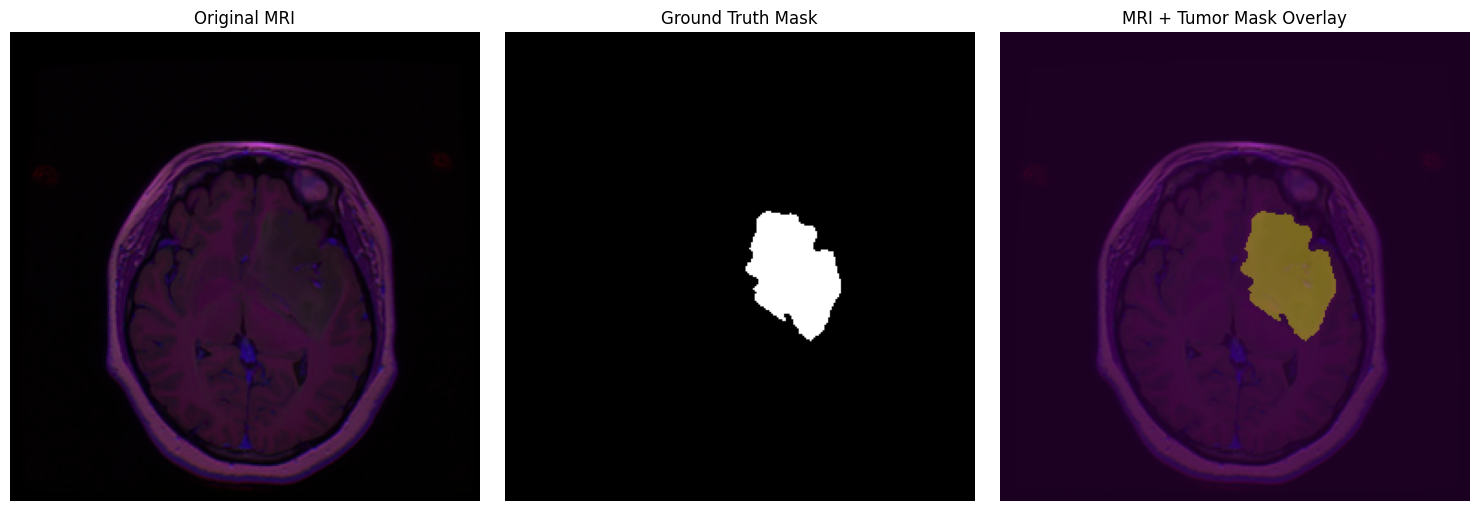

In [ ]:
#Visualize Tumor Sample


import random
import matplotlib.pyplot as plt
import tifffile
import numpy as np

# Find tumor-positive samples
tumor_pairs = []

for image_path, mask_path in pairs:
    mask = tifffile.imread(mask_path)

    if np.max(mask) > 0:
        tumor_pairs.append((image_path, mask_path))

# Select random tumor sample
image_path, mask_path = random.choice(tumor_pairs)

image = tifffile.imread(image_path)
mask = tifffile.imread(mask_path)

print("Image:", image_path.name)
print("Mask :", mask_path.name)

print("\nImage shape:", image.shape)
print("Mask shape :", mask.shape)

print("Image dtype:", image.dtype)
print("Mask dtype :", mask.dtype)

print("\nMask unique values:")
print(np.unique(mask))

# Display
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap="gray")
plt.title("Original MRI")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(image, cmap="gray")
plt.imshow(mask, alpha=0.4)
plt.title("MRI + Tumor Mask Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
#Find Images Without Masks
print("Images without corresponding masks:\n")

for image_path in missing_masks:
    print(image_path)

Images without corresponding masks:

/content/drive/MyDrive/labledataset/kaggle_3m/TCGA_CS_4941_19960909/Copy of Copy of TCGA_CS_4941_19960909_1 (1).tif
/content/drive/MyDrive/labledataset/kaggle_3m/TCGA_CS_4941_19960909/Copy of Copy of TCGA_CS_4941_19960909_1.tif
/content/drive/MyDrive/labledataset/kaggle_3m/TCGA_CS_4941_19960909/Copy of TCGA_CS_4941_19960909_5.tif


In [ ]:

# CELL 17: Create Dataset DataFrame


dataset_records = []

for image_path, mask_path in pairs:

    mask = tifffile.imread(mask_path)

    # 1 = tumor-positive
    # 0 = non-tumor
    has_tumor = int(np.max(mask) > 0)

    dataset_records.append({
        "image_path": str(image_path),
        "mask_path": str(mask_path),
        "has_tumor": has_tumor
    })

df = pd.DataFrame(dataset_records)

print("Dataset DataFrame created!")
print("\nShape:", df.shape)

print("\nFirst 5 records:")
display(df.head())

print("\nTumor distribution:")
print(df["has_tumor"].value_counts())

Dataset DataFrame created!

Shape: (3929, 3)

First 5 records:


,image_path,mask_path,has_tumor
0,/content/drive/MyDrive/labledataset/kaggle_3m/...,/content/drive/MyDrive/labledataset/kaggle_3m/...,0
1,/content/drive/MyDrive/labledataset/kaggle_3m/...,/content/drive/MyDrive/labledataset/kaggle_3m/...,0
2,/content/drive/MyDrive/labledataset/kaggle_3m/...,/content/drive/MyDrive/labledataset/kaggle_3m/...,0
3,/content/drive/MyDrive/labledataset/kaggle_3m/...,/content/drive/MyDrive/labledataset/kaggle_3m/...,0
4,/content/drive/MyDrive/labledataset/kaggle_3m/...,/content/drive/MyDrive/labledataset/kaggle_3m/...,0



Tumor distribution:
has_tumor
0    2556
1    1373
Name: count, dtype: int64


In [ ]:

# CELL 18: Train / Validation / Test Split


SEED = 42

# First: 70% train, 30% temporary
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=df["has_tumor"]
)

# Second: split the 30% into 15% validation and 15% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["has_tumor"]
)

print(" DATA SPLIT ")
print(f"Total      : {len(df)}")
print(f"Training   : {len(train_df)}")
print(f"Validation : {len(val_df)}")
print(f"Testing    : {len(test_df)}")


 DATA SPLIT 
Total      : 3929
Training   : 2750
Validation : 589
Testing    : 590


In [ ]:

# CELL 19: Check Split Distribution


def show_distribution(name, data):

    tumor = (data["has_tumor"] == 1).sum()
    non_tumor = (data["has_tumor"] == 0).sum()
    total = len(data)

    print(f"\n{name}")
    print("-" * 40)
    print(f"Total samples : {total}")
    print(f"Tumor         : {tumor} ({tumor/total*100:.2f}%)")
    print(f"Non-tumor     : {non_tumor} ({non_tumor/total*100:.2f}%)")


show_distribution("TRAINING SET", train_df)
show_distribution("VALIDATION SET", val_df)
show_distribution("TEST SET", test_df)


TRAINING SET
----------------------------------------
Total samples : 2750
Tumor         : 961 (34.95%)
Non-tumor     : 1789 (65.05%)

VALIDATION SET
----------------------------------------
Total samples : 589
Tumor         : 206 (34.97%)
Non-tumor     : 383 (65.03%)

TEST SET
----------------------------------------
Total samples : 590
Tumor         : 206 (34.92%)
Non-tumor     : 384 (65.08%)


In [ ]:
#Project Configuration
IMG_SIZE = 128
BATCH_SIZE = 4
NUM_EPOCHS = 30
LEARNING_RATE = 1e-4

NUM_WORKERS = 2

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("========== PROJECT CONFIGURATION ==========")
print("Image Size     :", IMG_SIZE)
print("Batch Size     :", BATCH_SIZE)
print("Epochs         :", NUM_EPOCHS)
print("Learning Rate  :", LEARNING_RATE)
print("Device         :", DEVICE)

if torch.cuda.is_available():
    print("GPU            :", torch.cuda.get_device_name(0))

========== PROJECT CONFIGURATION ==========
Image Size     : 128
Batch Size     : 4
Epochs         : 30
Learning Rate  : 0.0001
Device         : cuda
GPU            : Tesla T4


In [ ]:
#Data Augmentation

import albumentations as A
from albumentations.pytorch import ToTensorV2

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),

    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.Rotate(limit=15, p=0.5),

    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),

    ToTensorV2()
])

val_test_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),

    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),

    ToTensorV2()
])

print("Transforms created successfully!")

Transforms created successfully!


In [ ]:
#Brain Tumor Dataset


class BrainTumorDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        # Get paths
        image_path = self.dataframe.loc[index, "image_path"]
        mask_path = self.dataframe.loc[index, "mask_path"]

        # Load image
        image = tifffile.imread(image_path)

        # Load mask
        mask = tifffile.imread(mask_path)

        # Convert image to uint8 if necessary
        image = image.astype(np.uint8)

        # Convert mask to binary
        mask = (mask > 0).astype(np.uint8)

        # Apply transformations
        if self.transform:
            transformed = self.transform(
                image=image,
                mask=mask
            )

            image = transformed["image"]
            mask = transformed["mask"]

        # Ensure mask is float tensor
        mask = mask.float()

        return image, mask

In [ ]:

#  23: Create Dataset Objects


train_dataset = BrainTumorDataset(
    train_df,
    transform=train_transform
)

val_dataset = BrainTumorDataset(
    val_df,
    transform=val_test_transform
)

test_dataset = BrainTumorDataset(
    test_df,
    transform=val_test_transform
)

print("Dataset objects created successfully!")

print("\nTrain dataset :", len(train_dataset))
print("Validation    :", len(val_dataset))
print("Test dataset  :", len(test_dataset))

Dataset objects created successfully!

Train dataset : 2750
Validation    : 589
Test dataset  : 590


In [ ]:

#  24: Test Dataset Sample


image, mask = train_dataset[0]

print("Image shape :", image.shape)
print("Mask shape  :", mask.shape)

print("Image dtype :", image.dtype)
print("Mask dtype  :", mask.dtype)

print("Mask unique values :", torch.unique(mask))

Image shape : torch.Size([3, 128, 128])
Mask shape  : torch.Size([128, 128])
Image dtype : torch.float32
Mask dtype  : torch.float32
Mask unique values : tensor([0., 1.])


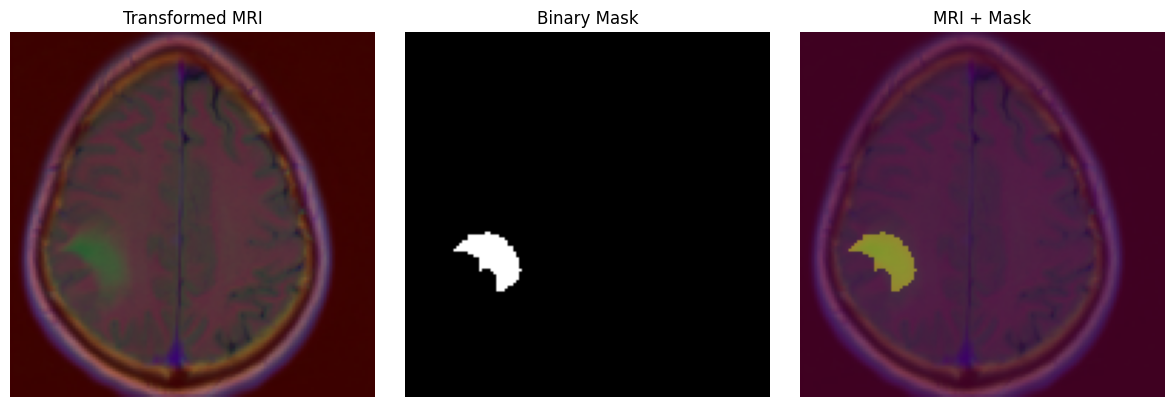

In [ ]:

#  25: Visualize Transformed Sample


image, mask = train_dataset[0]

# Convert image back for visualization
image_display = image.permute(1, 2, 0).numpy()

# Normalize back approximately
image_display = (
    image_display * np.array([0.229, 0.224, 0.225])
    + np.array([0.485, 0.456, 0.406])
)

image_display = np.clip(image_display, 0, 1)

mask_display = mask.numpy()

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(image_display)
plt.title("Transformed MRI")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask_display, cmap="gray")
plt.title("Binary Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(image_display)
plt.imshow(mask_display, alpha=0.4)
plt.title("MRI + Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:

#  Create DataLoaders


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("DataLoaders created successfully!")

print("\nTrain batches :", len(train_loader))
print("Val batches   :", len(val_loader))
print("Test batches  :", len(test_loader))

DataLoaders created successfully!

Train batches : 688
Val batches   : 148
Test batches  : 148


In [ ]:

# 27: Check DataLoader Batch

images, masks = next(iter(train_loader))

print("Images shape :", images.shape)
print("Masks shape  :", masks.shape)

print("Images dtype :", images.dtype)
print("Masks dtype  :", masks.dtype)

print("Images device:", images.device)
print("Masks unique values:", torch.unique(masks))

Images shape : torch.Size([4, 3, 128, 128])
Masks shape  : torch.Size([4, 128, 128])
Images dtype : torch.float32
Masks dtype  : torch.float32
Images device: cpu
Masks unique values: tensor([0., 1.])


In [ ]:

#  28: Segmentation Metrics


def dice_score(pred, target, smooth=1e-6):
    """
    Calculate Dice coefficient.

    pred   : predicted binary mask
    target : ground-truth binary mask
    """

    pred = pred.float()
    target = target.float()

    intersection = (pred * target).sum(dim=(1, 2))

    dice = (
        (2.0 * intersection + smooth)
        /
        (pred.sum(dim=(1, 2)) + target.sum(dim=(1, 2)) + smooth)
    )

    return dice.mean()


def iou_score(pred, target, smooth=1e-6):
    """
    Calculate Intersection over Union (IoU).
    """

    pred = pred.float()
    target = target.float()

    intersection = (pred * target).sum(dim=(1, 2))

    union = (
        pred.sum(dim=(1, 2))
        + target.sum(dim=(1, 2))
        - intersection
    )

    iou = (intersection + smooth) / (union + smooth)

    return iou.mean()


def precision_score(pred, target, smooth=1e-6):
    """
    Calculate pixel-level precision.
    """

    pred = pred.float()
    target = target.float()

    true_positive = (pred * target).sum(dim=(1, 2))
    false_positive = (pred * (1 - target)).sum(dim=(1, 2))

    precision = (
        (true_positive + smooth)
        /
        (true_positive + false_positive + smooth)
    )

    return precision.mean()


def recall_score(pred, target, smooth=1e-6):
    """
    Calculate pixel-level recall.
    """

    pred = pred.float()
    target = target.float()

    true_positive = (pred * target).sum(dim=(1, 2))
    false_negative = ((1 - pred) * target).sum(dim=(1, 2))

    recall = (
        (true_positive + smooth)
        /
        (true_positive + false_negative + smooth)
    )

    return recall.mean()


def pixel_accuracy(pred, target, smooth=1e-6):
    """
    Calculate pixel-wise accuracy.
    """

    pred = pred.float()
    target = target.float()

    correct = (pred == target).float().sum(dim=(1, 2))
    total = torch.tensor(
        pred.shape[1] * pred.shape[2],
        device=pred.device,
        dtype=torch.float32
    )

    accuracy = (correct + smooth) / (total + smooth)

    return accuracy.mean()

In [ ]:

#  29: Dice Loss


class DiceLoss(nn.Module):

    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):

        # Convert logits to probabilities
        probs = torch.sigmoid(logits)

        # Flatten spatial dimensions
        probs = probs.view(probs.size(0), -1)
        targets = targets.view(targets.size(0), -1)

        intersection = (probs * targets).sum(dim=1)

        dice = (
            (2.0 * intersection + self.smooth)
            /
            (
                probs.sum(dim=1)
                + targets.sum(dim=1)
                + self.smooth
            )
        )

        return 1 - dice.mean()

In [ ]:
#Combined Loss

class BCEDiceLoss(nn.Module):

    def __init__(self, bce_weight=0.5, dice_weight=0.5):
        super().__init__()

        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()

        self.bce_weight = bce_weight
        self.dice_weight = dice_weight

    def forward(self, logits, targets):

        bce_loss = self.bce(logits, targets)
        dice_loss = self.dice(logits, targets)

        total_loss = (
            self.bce_weight * bce_loss
            +
            self.dice_weight * dice_loss
        )

        return total_loss

In [ ]:

#  31: Test Metrics


# Get one batch
images, masks = next(iter(train_loader))

# Create dummy prediction
dummy_pred = (torch.rand_like(masks) > 0.5).float()

print("Dice      :", dice_score(dummy_pred, masks).item())
print("IoU       :", iou_score(dummy_pred, masks).item())
print("Precision :", precision_score(dummy_pred, masks).item())
print("Recall    :", recall_score(dummy_pred, masks).item())
print("Accuracy  :", pixel_accuracy(dummy_pred, masks).item())

Dice      : 1.2176511188233263e-10
IoU       : 1.2176511188233263e-10
Precision : 1.2176511188233263e-10
Recall    : 1.0
Accuracy  : 0.4987335205078125


In [ ]:
# ============================================
#  32: Double Convolution Block
# ============================================

class DoubleConv(nn.Module):
    """
    Two consecutive convolution blocks.

    Each block:
        Conv2d
        BatchNorm2d
        ReLU
    """

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.double_conv = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

In [ ]:
# ============================================
# CELL 33: Vanilla U-Net
# ============================================

class VanillaUNet(nn.Module):

    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()

        # -------------------------
        # Encoder
        # -------------------------

        self.enc1 = DoubleConv(in_channels, 64)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.enc2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.enc3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.enc4 = DoubleConv(256, 512)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)

        # -------------------------
        # Bottleneck
        # -------------------------

        self.bottleneck = DoubleConv(512, 1024)

        # -------------------------
        # Decoder
        # -------------------------

        self.up4 = nn.ConvTranspose2d(
            1024, 512,
            kernel_size=2,
            stride=2
        )
        self.dec4 = DoubleConv(1024, 512)

        self.up3 = nn.ConvTranspose2d(
            512, 256,
            kernel_size=2,
            stride=2
        )
        self.dec3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(
            256, 128,
            kernel_size=2,
            stride=2
        )
        self.dec2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(
            128, 64,
            kernel_size=2,
            stride=2
        )
        self.dec1 = DoubleConv(128, 64)

        # -------------------------
        # Final Segmentation Layer
        # -------------------------

        self.final_conv = nn.Conv2d(
            64,
            out_channels,
            kernel_size=1
        )

    def forward(self, x):

        # ====================================
        # ENCODER
        # ====================================

        # Encoder 1
        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        # Encoder 2
        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        # Encoder 3
        e3 = self.enc3(p2)
        p3 = self.pool3(e3)

        # Encoder 4
        e4 = self.enc4(p3)
        p4 = self.pool4(e4)

        # ====================================
        # BOTTLENECK
        # ====================================

        b = self.bottleneck(p4)

        # ====================================
        # DECODER
        # ====================================

        # Decoder 4
        d4 = self.up4(b)

        # Skip connection
        d4 = torch.cat([d4, e4], dim=1)

        d4 = self.dec4(d4)

        # Decoder 3
        d3 = self.up3(d4)

        # Skip connection
        d3 = torch.cat([d3, e3], dim=1)

        d3 = self.dec3(d3)

        # Decoder 2
        d2 = self.up2(d3)

        # Skip connection
        d2 = torch.cat([d2, e2], dim=1)

        d2 = self.dec2(d2)

        # Decoder 1
        d1 = self.up1(d2)

        # Skip connection
        d1 = torch.cat([d1, e1], dim=1)

        d1 = self.dec1(d1)

        # ====================================
        # FINAL OUTPUT
        # ====================================

        output = self.final_conv(d1)

        return output

In [ ]:

# Create Vanilla U-Net Model


vanilla_unet = VanillaUNet(
    in_channels=3,
    out_channels=1
)

vanilla_unet = vanilla_unet.to(DEVICE)

print(vanilla_unet)

VanillaUNet(
  (enc1): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inp

In [ ]:
#Model Parameters
total_params = sum(
    p.numel()
    for p in vanilla_unet.parameters()
)

trainable_params = sum(
    p.numel()
    for p in vanilla_unet.parameters()
    if p.requires_grad
)

print("Total parameters    :", f"{total_params:,}")
print("Trainable parameters:", f"{trainable_params:,}")

Total parameters    : 31,043,521
Trainable parameters: 31,043,521


In [ ]:

#  Test Forward Pass


# Get one batch
images, masks = next(iter(train_loader))

# Move batch to GPU
images = images.to(DEVICE)
masks = masks.to(DEVICE)

# Disable gradient for this test
with torch.no_grad():

    outputs = vanilla_unet(images)

print("Input shape :", images.shape)
print("Output shape:", outputs.shape)
print("Target shape:", masks.shape)

Input shape : torch.Size([4, 3, 128, 128])
Output shape: torch.Size([4, 1, 128, 128])
Target shape: torch.Size([4, 128, 128])


In [ ]:
# Loss Function & Optimizer


criterion = BCEDiceLoss(
    bce_weight=0.5,
    dice_weight=0.5
)

optimizer = torch.optim.Adam(
    vanilla_unet.parameters(),
    lr=LEARNING_RATE
)

print("Loss      : BCE + Dice")
print("Optimizer : Adam")
print("Learning rate:", LEARNING_RATE)

Loss      : BCE + Dice
Optimizer : Adam
Learning rate: 0.0001


In [ ]:
#  38: Training Function


def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0

    for images, masks in loader:

        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        # Add channel dimension
        masks = masks.unsqueeze(1)

        # Clear gradients
        optimizer.zero_grad(set_to_none=True)

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, masks)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Convert prediction to binary mask
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        # Remove channel dimension for metrics
        preds_metric = preds.squeeze(1)
        masks_metric = masks.squeeze(1)

        # Metrics
        dice = dice_score(preds_metric, masks_metric)
        iou = iou_score(preds_metric, masks_metric)

        running_loss += loss.item()
        running_dice += dice.item()
        running_iou += iou.item()

    epoch_loss = running_loss / len(loader)
    epoch_dice = running_dice / len(loader)
    epoch_iou = running_iou / len(loader)

    return epoch_loss, epoch_dice, epoch_iou

In [ ]:
#  39: Validation Function


def validate_one_epoch(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0

    with torch.no_grad():

        for images, masks in loader:

            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            masks = masks.unsqueeze(1)

            # Forward pass
            outputs = model(images)

            # Loss
            loss = criterion(outputs, masks)

            # Prediction
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()

            preds_metric = preds.squeeze(1)
            masks_metric = masks.squeeze(1)

            # Metrics
            dice = dice_score(preds_metric, masks_metric)
            iou = iou_score(preds_metric, masks_metric)

            running_loss += loss.item()
            running_dice += dice.item()
            running_iou += iou.item()

    epoch_loss = running_loss / len(loader)
    epoch_dice = running_dice / len(loader)
    epoch_iou = running_iou / len(loader)

    return epoch_loss, epoch_dice, epoch_iou

In [ ]:
#  Vanilla U-Net Smoke Test


SMOKE_TEST_EPOCHS = 3

best_val_dice = -1.0

for epoch in range(1, SMOKE_TEST_EPOCHS + 1):

    train_loss, train_dice, train_iou = train_one_epoch(
        vanilla_unet,
        train_loader,
        criterion,
        optimizer,
        DEVICE
    )

    val_loss, val_dice, val_iou = validate_one_epoch(
        vanilla_unet,
        val_loader,
        criterion,
        DEVICE
    )

    print(
        f"Epoch [{epoch}/{SMOKE_TEST_EPOCHS}]"
    )

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Dice: {train_dice:.4f} | "
        f"IoU: {train_iou:.4f}"
    )

    print(
        f"Val Loss:   {val_loss:.4f} | "
        f"Dice: {val_dice:.4f} | "
        f"IoU: {val_iou:.4f}"
    )

    print("-" * 60)

    # Save best checkpoint
    if val_dice > best_val_dice:

        best_val_dice = val_dice

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": vanilla_unet.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_dice": val_dice,
                "val_iou": val_iou,
                "val_loss": val_loss
            },
            "/content/drive/MyDrive/labledataset/vanilla_unet_smoke_best.pth"
        )

        print("✓ Best smoke-test model saved!")

Epoch [1/3]
Train Loss: 0.6126 | Dice: 0.5454 | IoU: 0.5113
Val Loss:   0.5351 | Dice: 0.6722 | IoU: 0.6318
------------------------------------------------------------
✓ Best smoke-test model saved!
Epoch [2/3]
Train Loss: 0.4944 | Dice: 0.5686 | IoU: 0.5322
Val Loss:   0.4526 | Dice: 0.7180 | IoU: 0.6793
------------------------------------------------------------
✓ Best smoke-test model saved!
Epoch [3/3]
Train Loss: 0.4410 | Dice: 0.5604 | IoU: 0.5232
Val Loss:   0.4190 | Dice: 0.6576 | IoU: 0.6186
------------------------------------------------------------


In [ ]:

#  41: Final Training Configuration


MAX_EPOCHS = 30
PATIENCE = 7

BEST_MODEL_PATH = (
    "/content/drive/MyDrive/labledataset/"
    "vanilla_unet_best.pth"
)

print("Maximum epochs :", MAX_EPOCHS)
print("Early stopping :", PATIENCE)
print("Checkpoint     :", BEST_MODEL_PATH)

Maximum epochs : 30
Early stopping : 7
Checkpoint     : /content/drive/MyDrive/labledataset/vanilla_unet_best.pth


In [ ]:

#  42: Final Vanilla U-Net Training


train_history = {
    "loss": [],
    "dice": [],
    "iou": []
}

val_history = {
    "loss": [],
    "dice": [],
    "iou": []
}

best_val_dice = -1.0
patience_counter = 0

for epoch in range(1, MAX_EPOCHS + 1):

    # ----------------------------------------
    # Training
    # ----------------------------------------

    train_loss, train_dice, train_iou = train_one_epoch(
        vanilla_unet,
        train_loader,
        criterion,
        optimizer,
        DEVICE
    )

    # ----------------------------------------
    # Validation
    # ----------------------------------------

    val_loss, val_dice, val_iou = validate_one_epoch(
        vanilla_unet,
        val_loader,
        criterion,
        DEVICE
    )

    # ----------------------------------------
    # Store history
    # ----------------------------------------

    train_history["loss"].append(train_loss)
    train_history["dice"].append(train_dice)
    train_history["iou"].append(train_iou)

    val_history["loss"].append(val_loss)
    val_history["dice"].append(val_dice)
    val_history["iou"].append(val_iou)

    # ----------------------------------------
    # Print results
    # ----------------------------------------

    print(f"\nEpoch [{epoch}/{MAX_EPOCHS}]")

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Dice: {train_dice:.4f} | "
        f"IoU: {train_iou:.4f}"
    )

    print(
        f"Val Loss:   {val_loss:.4f} | "
        f"Dice: {val_dice:.4f} | "
        f"IoU: {val_iou:.4f}"
    )

    # ----------------------------------------
    # Check improvement
    # ----------------------------------------

    if val_dice > best_val_dice:

        best_val_dice = val_dice
        patience_counter = 0

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": vanilla_unet.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "best_val_dice": best_val_dice,
                "val_iou": val_iou,
                "val_loss": val_loss
            },
            BEST_MODEL_PATH
        )

        print(
            f"✓ Best model saved! "
            f"Val Dice = {best_val_dice:.4f}"
        )

    else:

        patience_counter += 1

        print(
            f"No improvement "
            f"({patience_counter}/{PATIENCE})"
        )

    # ----------------------------------------
    # Early stopping
    # ----------------------------------------

    if patience_counter >= PATIENCE:

        print("\nEarly stopping triggered.")
        print(f"Best Validation Dice: {best_val_dice:.4f}")
        break

print("\n============================================")
print("Vanilla U-Net training completed!")
print("Best Validation Dice:", f"{best_val_dice:.4f}")
print("============================================")


Epoch [1/30]
Train Loss: 0.4130 | Dice: 0.5330 | IoU: 0.4935
Val Loss:   0.3944 | Dice: 0.6193 | IoU: 0.5796
✓ Best model saved! Val Dice = 0.6193

Epoch [2/30]
Train Loss: 0.3970 | Dice: 0.5610 | IoU: 0.5214
Val Loss:   0.3883 | Dice: 0.7754 | IoU: 0.7351
✓ Best model saved! Val Dice = 0.7754

Epoch [3/30]
Train Loss: 0.3880 | Dice: 0.5609 | IoU: 0.5225
Val Loss:   0.3765 | Dice: 0.7562 | IoU: 0.7195
No improvement (1/7)

Epoch [4/30]
Train Loss: 0.3822 | Dice: 0.5919 | IoU: 0.5546
Val Loss:   0.3737 | Dice: 0.4954 | IoU: 0.4594
No improvement (2/7)

Epoch [5/30]
Train Loss: 0.3775 | Dice: 0.6095 | IoU: 0.5727
Val Loss:   0.3751 | Dice: 0.7050 | IoU: 0.6701
No improvement (3/7)

Epoch [6/30]
Train Loss: 0.3740 | Dice: 0.6508 | IoU: 0.6159
Val Loss:   0.3687 | Dice: 0.7837 | IoU: 0.7498
✓ Best model saved! Val Dice = 0.7837

Epoch [7/30]
Train Loss: 0.3714 | Dice: 0.6626 | IoU: 0.6277
Val Loss:   0.3728 | Dice: 0.4942 | IoU: 0.4582
No improvement (1/7)

Epoch [8/30]
Train Loss: 0.3711

In [ ]:
# Load Best Vanilla U-Net


checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE
)

vanilla_unet.load_state_dict(
    checkpoint["model_state_dict"]
)

vanilla_unet = vanilla_unet.to(DEVICE)

print("Best Vanilla U-Net loaded successfully!")

print("Best epoch:",
      checkpoint["epoch"])

print("Best Val Dice:",
      f"{checkpoint['best_val_dice']:.4f}")

print("Best Val IoU:",
      f"{checkpoint['val_iou']:.4f}")

Best Vanilla U-Net loaded successfully!
Best epoch: 8
Best Val Dice: 0.8133
Best Val IoU: 0.7796


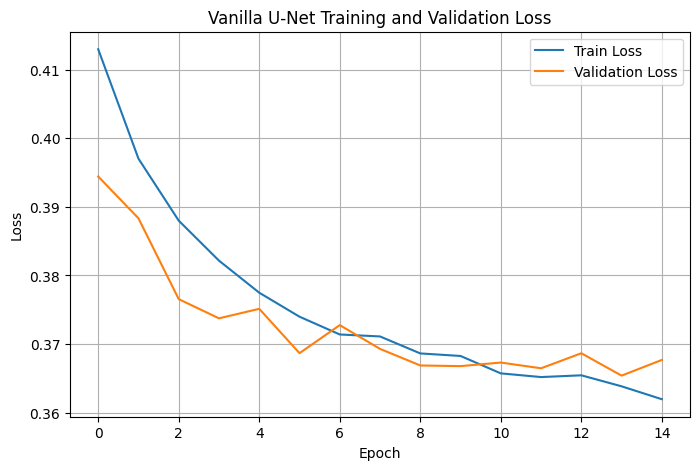

In [ ]:
#  Training & Validation Loss


plt.figure(figsize=(8, 5))

plt.plot(
    train_history["loss"],
    label="Train Loss"
)

plt.plot(
    val_history["loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Vanilla U-Net Training and Validation Loss")

plt.legend()
plt.grid(True)
plt.show()

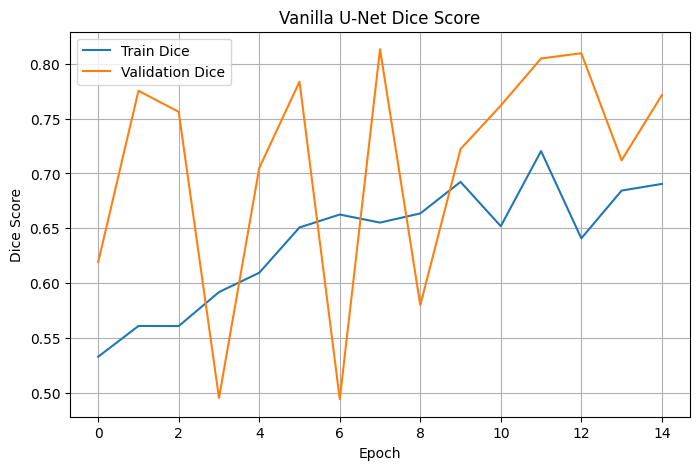

In [ ]:
# 45: Dice Score Curve


plt.figure(figsize=(8, 5))

plt.plot(
    train_history["dice"],
    label="Train Dice"
)

plt.plot(
    val_history["dice"],
    label="Validation Dice"
)

plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.title("Vanilla U-Net Dice Score")

plt.legend()
plt.grid(True)
plt.show()

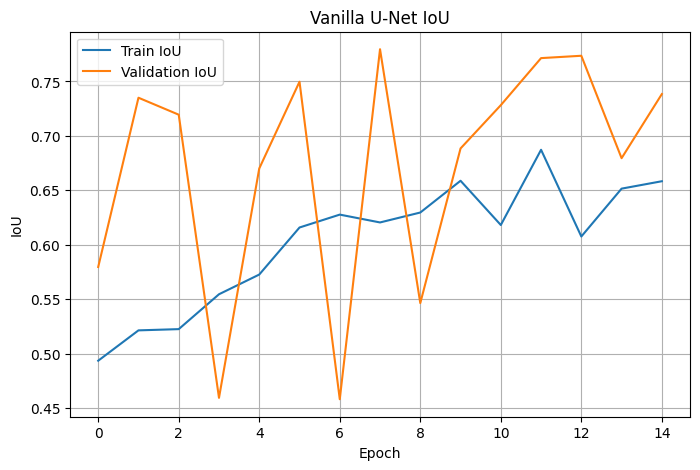

In [ ]:
# IoU Curve


plt.figure(figsize=(8, 5))

plt.plot(
    train_history["iou"],
    label="Train IoU"
)

plt.plot(
    val_history["iou"],
    label="Validation IoU"
)

plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title("Vanilla U-Net IoU")

plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#  47: Vanilla U-Net Test Evaluation


# Load best validation checkpoint
checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE
)

vanilla_unet.load_state_dict(
    checkpoint["model_state_dict"]
)

vanilla_unet = vanilla_unet.to(DEVICE)
vanilla_unet.eval()


# Store results
test_loss = 0.0
test_dice = 0.0
test_iou = 0.0

all_predictions = []
all_masks = []


with torch.no_grad():

    for images, masks in test_loader:

        # Move to Tesla T4
        images = images.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)

        # Add channel dimension
        masks_channel = masks.unsqueeze(1)

        # Prediction
        outputs = vanilla_unet(images)

        # Loss
        loss = criterion(outputs, masks_channel)

        # Probability
        probs = torch.sigmoid(outputs)

        # Binary prediction
        preds = (probs > 0.5).float()

        # Metrics
        preds_metric = preds.squeeze(1)

        dice = dice_score(
            preds_metric,
            masks
        )

        iou = iou_score(
            preds_metric,
            masks
        )

        test_loss += loss.item()
        test_dice += dice.item()
        test_iou += iou.item()

        # Store for later metrics
        all_predictions.append(
            preds_metric.cpu()
        )

        all_masks.append(
            masks.cpu()
        )


# Average test results
test_loss /= len(test_loader)
test_dice /= len(test_loader)
test_iou /= len(test_loader)


print("=" * 60)
print("VANILLA U-NET TEST RESULTS")
print("=" * 60)

print(f"Test Loss : {test_loss:.4f}")
print(f"Test Dice : {test_dice:.4f}")
print(f"Test IoU  : {test_iou:.4f}")

print("=" * 60)

VANILLA U-NET TEST RESULTS
Test Loss : 0.3681
Test Dice : 0.8030
Test IoU  : 0.7718


In [ ]:
# 48: Test Precision, Recall, Accuracy


predictions = torch.cat(all_predictions, dim=0)
ground_truth = torch.cat(all_masks, dim=0)

# Flatten all pixels
pred_flat = predictions.reshape(-1)
mask_flat = ground_truth.reshape(-1)


# True Positive
TP = ((pred_flat == 1) & (mask_flat == 1)).sum().item()

# True Negative
TN = ((pred_flat == 0) & (mask_flat == 0)).sum().item()

# False Positive
FP = ((pred_flat == 1) & (mask_flat == 0)).sum().item()

# False Negative
FN = ((pred_flat == 0) & (mask_flat == 1)).sum().item()


EPS = 1e-7

precision = TP / (TP + FP + EPS)

recall = TP / (TP + FN + EPS)

accuracy = (TP + TN) / (
    TP + TN + FP + FN + EPS
)


print("=" * 60)
print("VANILLA U-NET FINAL TEST METRICS")
print("=" * 60)

print(f"Dice      : {test_dice:.4f}")
print(f"IoU       : {test_iou:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"Accuracy  : {accuracy:.4f}")

print("=" * 60)

VANILLA U-NET FINAL TEST METRICS
Dice      : 0.8030
IoU       : 0.7718
Precision : 0.8361
Recall    : 0.8742
Accuracy  : 0.9969


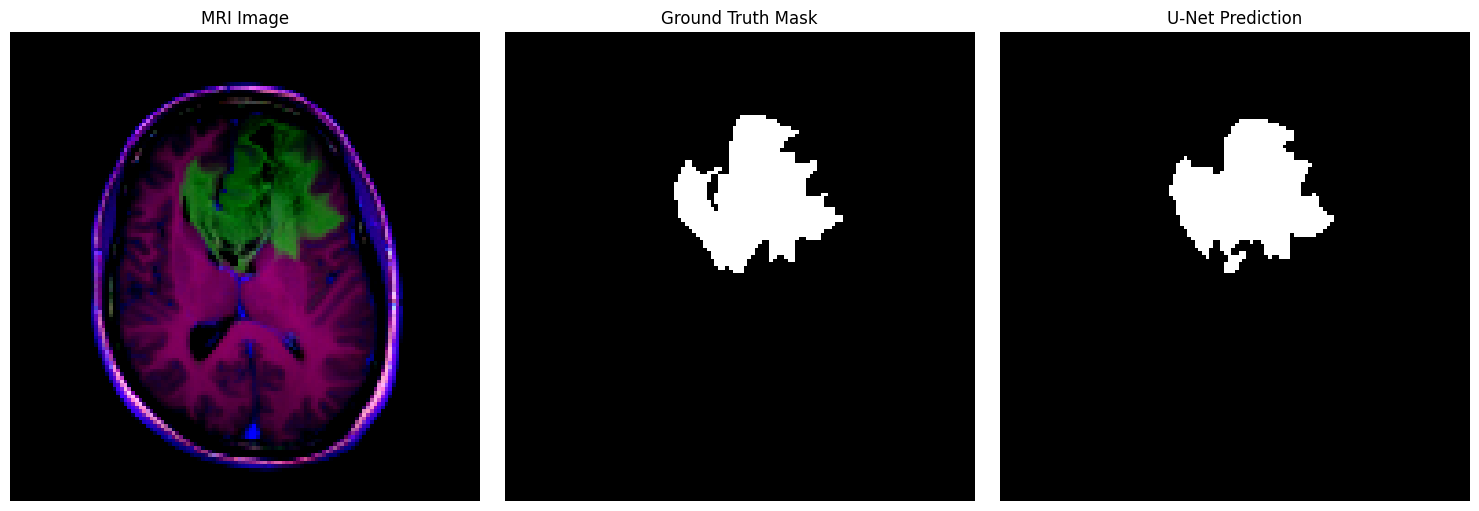

In [ ]:
#  49: Visualize Test Predictions


import random
import matplotlib.pyplot as plt

# Random test batch
images, masks = next(iter(test_loader))

images_gpu = images.to(DEVICE)

with torch.no_grad():
    outputs = vanilla_unet(images_gpu)
    probs = torch.sigmoid(outputs)
    preds = (probs > 0.5).float()

# Move to CPU
images = images.cpu()
masks = masks.cpu()
preds = preds.squeeze(1).cpu()


# Select one random sample
idx = random.randint(0, len(images) - 1)

image = images[idx]
mask = masks[idx]
prediction = preds[idx]


# Convert CHW -> HWC
image_np = image.permute(1, 2, 0).numpy()

# Denormalization for visualization
image_np = image_np * 0.5 + 0.5

image_np = image_np.clip(0, 1)


plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_np)
plt.title("MRI Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(prediction, cmap="gray")
plt.title("U-Net Prediction")
plt.axis("off")

plt.tight_layout()
plt.show()

#VGG16-based Segmentation

In [ ]:

#  50: VGG16 Imports


import torch
import torch.nn as nn
from torchvision.models import vgg16, VGG16_Weights

print("VGG16 imports successful!")

VGG16 imports successful!


In [ ]:
#VGG16-Based Segmentation Model

class VGG16Segmentation(nn.Module):

    def __init__(self, in_channels=3, out_channels=1):

        super().__init__()

        # ----------------------------------------
        # VGG16 Encoder
        # ----------------------------------------

        weights = VGG16_Weights.DEFAULT

        vgg = vgg16(weights=weights)

        # VGG16 convolutional feature extractor
        self.encoder = vgg.features

        # ----------------------------------------
        # Decoder
        # ----------------------------------------

        self.decoder = nn.Sequential(

            # 512 -> 256
            nn.ConvTranspose2d(
                512, 256,
                kernel_size=2,
                stride=2
            ),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            # 256 -> 128
            nn.ConvTranspose2d(
                256, 128,
                kernel_size=2,
                stride=2
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            # 128 -> 64
            nn.ConvTranspose2d(
                128, 64,
                kernel_size=2,
                stride=2
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            # 64 -> 32
            nn.ConvTranspose2d(
                64, 32,
                kernel_size=2,
                stride=2
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            # 32 -> 16
            nn.ConvTranspose2d(
                32, 16,
                kernel_size=2,
                stride=2
            ),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),

            # Final segmentation layer
            nn.Conv2d(
                16,
                out_channels,
                kernel_size=1
            )
        )

    def forward(self, x):

        # VGG16 feature extraction
        x = self.encoder(x)

        # Decoder reconstructs segmentation map
        x = self.decoder(x)

        return x

In [ ]:
# Create VGG16 Segmentation Model

vgg16_model = VGG16Segmentation(
    in_channels=3,
    out_channels=1
)

vgg16_model = vgg16_model.to(DEVICE)

print("VGG16 Segmentation model created successfully!")

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 148MB/s]


VGG16 Segmentation model created successfully!


In [ ]:
#  53: VGG16 Model Parameters


total_params = sum(
    p.numel()
    for p in vgg16_model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in vgg16_model.parameters()
    if p.requires_grad
)

print("Total parameters    :", f"{total_params:,}")
print("Trainable parameters:", f"{trainable_params:,}")

Total parameters    : 15,414,561
Trainable parameters: 15,414,561


In [ ]:
#  54: VGG16 Forward Pass Test

images, masks = next(iter(train_loader))

images = images.to(DEVICE)
masks = masks.to(DEVICE)

with torch.no_grad():

    outputs = vgg16_model(images)

print("Input shape :", images.shape)
print("Output shape:", outputs.shape)
print("Target shape:", masks.shape)

Input shape : torch.Size([4, 3, 128, 128])
Output shape: torch.Size([4, 1, 128, 128])
Target shape: torch.Size([4, 128, 128])


In [ ]:

# 55: VGG16 Loss & Optimizer


vgg16_criterion = BCEDiceLoss(
    bce_weight=0.5,
    dice_weight=0.5
)

vgg16_optimizer = torch.optim.Adam(
    vgg16_model.parameters(),
    lr=LEARNING_RATE
)

print("Loss      : BCE + Dice")
print("Optimizer : Adam")
print("Learning rate:", LEARNING_RATE)

Loss      : BCE + Dice
Optimizer : Adam
Learning rate: 0.0001


In [ ]:
# VGG16 Smoke-Test Training


VGG16_SMOKE_EPOCHS = 3

vgg16_best_val_dice = -1.0

for epoch in range(1, VGG16_SMOKE_EPOCHS + 1):

    train_loss, train_dice, train_iou = train_one_epoch(
        vgg16_model,
        train_loader,
        vgg16_criterion,
        vgg16_optimizer,
        DEVICE
    )

    val_loss, val_dice, val_iou = validate_one_epoch(
        vgg16_model,
        val_loader,
        vgg16_criterion,
        DEVICE
    )

    print(f"\nEpoch [{epoch}/{VGG16_SMOKE_EPOCHS}]")

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Dice: {train_dice:.4f} | "
        f"IoU: {train_iou:.4f}"
    )

    print(
        f"Val Loss:   {val_loss:.4f} | "
        f"Dice: {val_dice:.4f} | "
        f"IoU: {val_iou:.4f}"
    )

    print("-" * 60)

    # Save best smoke-test model
    if val_dice > vgg16_best_val_dice:

        vgg16_best_val_dice = val_dice

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": vgg16_model.state_dict(),
                "optimizer_state_dict": vgg16_optimizer.state_dict(),
                "val_dice": val_dice,
                "val_iou": val_iou,
                "val_loss": val_loss
            },
            "/content/drive/MyDrive/labledataset/"
            "vgg16_smoke_best.pth"
        )

        print("✓ Best VGG16 smoke-test model saved!")


Epoch [1/3]
Train Loss: 0.7021 | Dice: 0.0888 | IoU: 0.0620
Val Loss:   0.6441 | Dice: 0.1903 | IoU: 0.1432
------------------------------------------------------------
✓ Best VGG16 smoke-test model saved!

Epoch [2/3]
Train Loss: 0.6049 | Dice: 0.5846 | IoU: 0.5405
Val Loss:   0.5633 | Dice: 0.7704 | IoU: 0.7267
------------------------------------------------------------
✓ Best VGG16 smoke-test model saved!

Epoch [3/3]
Train Loss: 0.5454 | Dice: 0.7636 | IoU: 0.7153
Val Loss:   0.5092 | Dice: 0.8454 | IoU: 0.8042
------------------------------------------------------------
✓ Best VGG16 smoke-test model saved!


In [ ]:
# GPU Check
if torch.cuda.is_available():

    print("GPU:", torch.cuda.get_device_name(0))

    allocated = torch.cuda.memory_allocated() / (1024 ** 3)
    reserved = torch.cuda.memory_reserved() / (1024 ** 3)

    print(f"GPU memory allocated: {allocated:.2f} GB")
    print(f"GPU memory reserved : {reserved:.2f} GB")

GPU: Tesla T4
GPU memory allocated: 1.06 GB
GPU memory reserved : 1.30 GB


In [ ]:
#58: Final VGG16 Training Configuration


VGG16_MAX_EPOCHS = 30
VGG16_PATIENCE = 7

VGG16_BEST_MODEL_PATH = (
    "/content/drive/MyDrive/labledataset/"
    "vgg16_best.pth"
)

print("Maximum epochs :", VGG16_MAX_EPOCHS)
print("Early stopping :", VGG16_PATIENCE)
print("Checkpoint     :", VGG16_BEST_MODEL_PATH)

Maximum epochs : 30
Early stopping : 7
Checkpoint     : /content/drive/MyDrive/labledataset/vgg16_best.pth


In [ ]:
#  Final VGG16 Training

vgg16_train_history = {
    "loss": [],
    "dice": [],
    "iou": []
}

vgg16_val_history = {
    "loss": [],
    "dice": [],
    "iou": []
}

best_vgg16_val_dice = -1.0
vgg16_patience_counter = 0


for epoch in range(1, VGG16_MAX_EPOCHS + 1):

    # ----------------------------------------
    # Training
    # ----------------------------------------

    train_loss, train_dice, train_iou = train_one_epoch(
        vgg16_model,
        train_loader,
        vgg16_criterion,
        vgg16_optimizer,
        DEVICE
    )

    # ----------------------------------------
    # Validation
    # ----------------------------------------

    val_loss, val_dice, val_iou = validate_one_epoch(
        vgg16_model,
        val_loader,
        vgg16_criterion,
        DEVICE
    )

    # ----------------------------------------
    # Store history
    # ----------------------------------------

    vgg16_train_history["loss"].append(train_loss)
    vgg16_train_history["dice"].append(train_dice)
    vgg16_train_history["iou"].append(train_iou)

    vgg16_val_history["loss"].append(val_loss)
    vgg16_val_history["dice"].append(val_dice)
    vgg16_val_history["iou"].append(val_iou)

    # ----------------------------------------
    # Display results
    # ----------------------------------------

    print(f"\nEpoch [{epoch}/{VGG16_MAX_EPOCHS}]")

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Dice: {train_dice:.4f} | "
        f"IoU: {train_iou:.4f}"
    )

    print(
        f"Val Loss:   {val_loss:.4f} | "
        f"Dice: {val_dice:.4f} | "
        f"IoU: {val_iou:.4f}"
    )

    # ----------------------------------------
    # Save best model
    # ----------------------------------------

    if val_dice > best_vgg16_val_dice:

        best_vgg16_val_dice = val_dice
        vgg16_patience_counter = 0

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": vgg16_model.state_dict(),
                "optimizer_state_dict": vgg16_optimizer.state_dict(),
                "best_val_dice": best_vgg16_val_dice,
                "val_iou": val_iou,
                "val_loss": val_loss
            },
            VGG16_BEST_MODEL_PATH
        )

        print(
            f"✓ Best VGG16 model saved! "
            f"Val Dice = {best_vgg16_val_dice:.4f}"
        )

    else:

        vgg16_patience_counter += 1

        print(
            f"No improvement "
            f"({vgg16_patience_counter}/{VGG16_PATIENCE})"
        )

    # ----------------------------------------
    # Early stopping
    # ----------------------------------------

    if vgg16_patience_counter >= VGG16_PATIENCE:

        print("\nEarly stopping triggered.")

        print(
            f"Best Validation Dice: "
            f"{best_vgg16_val_dice:.4f}"
        )

        break


print("\n============================================")
print("VGG16 training completed!")
print(
    "Best Validation Dice:",
    f"{best_vgg16_val_dice:.4f}"
)
print("============================================")


Epoch [1/30]
Train Loss: 0.4842 | Dice: 0.7575 | IoU: 0.7123
Val Loss:   0.4588 | Dice: 0.8679 | IoU: 0.8254
✓ Best VGG16 model saved! Val Dice = 0.8679

Epoch [2/30]
Train Loss: 0.4419 | Dice: 0.8363 | IoU: 0.7927
Val Loss:   0.4274 | Dice: 0.8630 | IoU: 0.8195
No improvement (1/7)

Epoch [3/30]
Train Loss: 0.4187 | Dice: 0.8119 | IoU: 0.7685
Val Loss:   0.4058 | Dice: 0.8284 | IoU: 0.7845
No improvement (2/7)

Epoch [4/30]
Train Loss: 0.4026 | Dice: 0.8315 | IoU: 0.7887
Val Loss:   0.3982 | Dice: 0.8727 | IoU: 0.8289
✓ Best VGG16 model saved! Val Dice = 0.8727

Epoch [5/30]
Train Loss: 0.3926 | Dice: 0.8386 | IoU: 0.7958
Val Loss:   0.3938 | Dice: 0.8696 | IoU: 0.8265
No improvement (1/7)

Epoch [6/30]
Train Loss: 0.3855 | Dice: 0.8667 | IoU: 0.8247
Val Loss:   0.3904 | Dice: 0.8746 | IoU: 0.8322
✓ Best VGG16 model saved! Val Dice = 0.8746

Epoch [7/30]
Train Loss: 0.3816 | Dice: 0.8548 | IoU: 0.8132
Val Loss:   0.3847 | Dice: 0.8794 | IoU: 0.8380
✓ Best VGG16 model saved! Val Dice 

In [ ]:
# 60: Load Best VGG16 Model


vgg16_checkpoint = torch.load(
    VGG16_BEST_MODEL_PATH,
    map_location=DEVICE
)

vgg16_model.load_state_dict(
    vgg16_checkpoint["model_state_dict"]
)

vgg16_model = vgg16_model.to(DEVICE)

print("Best VGG16 model loaded successfully!")

print(
    "Best epoch:",
    vgg16_checkpoint["epoch"]
)

print(
    "Best Val Dice:",
    f"{vgg16_checkpoint['best_val_dice']:.4f}"
)

print(
    "Best Val IoU:",
    f"{vgg16_checkpoint['val_iou']:.4f}"
)

Best VGG16 model loaded successfully!
Best epoch: 7
Best Val Dice: 0.8794
Best Val IoU: 0.8380


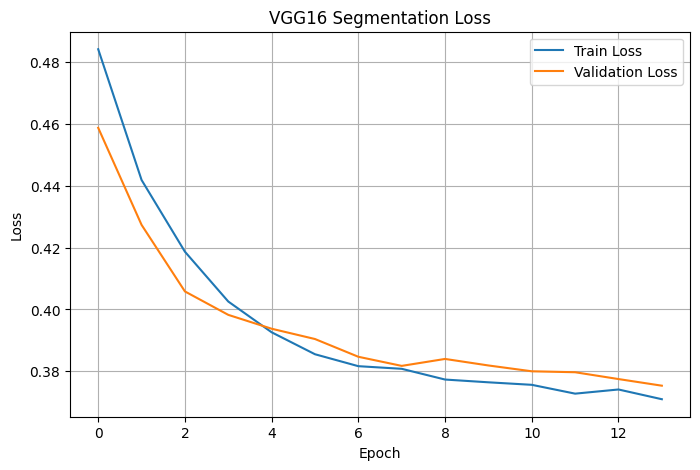

In [ ]:
# VGG16 Loss Curve


plt.figure(figsize=(8, 5))

plt.plot(
    vgg16_train_history["loss"],
    label="Train Loss"
)

plt.plot(
    vgg16_val_history["loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VGG16 Segmentation Loss")

plt.legend()
plt.grid(True)
plt.show()

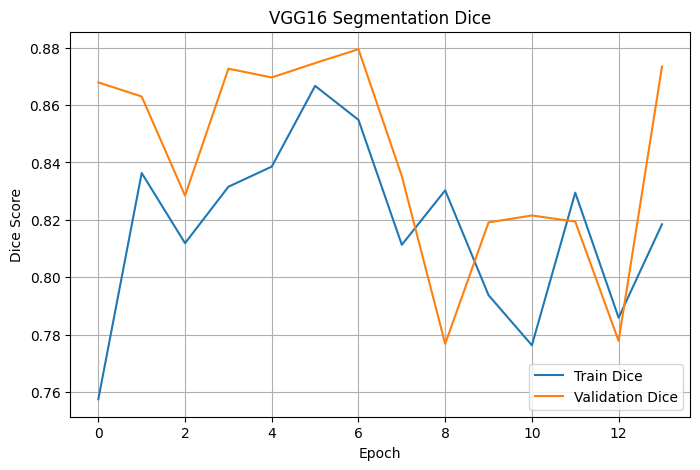

In [ ]:
#  62: VGG16 Dice Curve


plt.figure(figsize=(8, 5))

plt.plot(
    vgg16_train_history["dice"],
    label="Train Dice"
)

plt.plot(
    vgg16_val_history["dice"],
    label="Validation Dice"
)

plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.title("VGG16 Segmentation Dice")

plt.legend()
plt.grid(True)
plt.show()

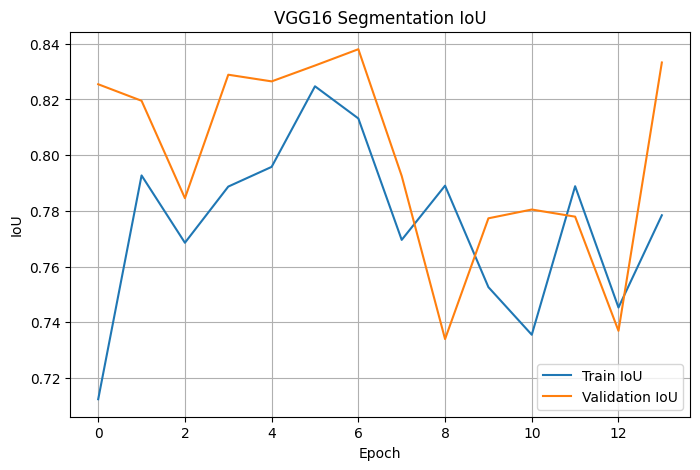

In [ ]:
#VGG16 IoU Curve


plt.figure(figsize=(8, 5))

plt.plot(
    vgg16_train_history["iou"],
    label="Train IoU"
)

plt.plot(
    vgg16_val_history["iou"],
    label="Validation IoU"
)

plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title("VGG16 Segmentation IoU")

plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# 64: VGG16 Test Evaluation


vgg16_model.eval()

vgg16_test_loss = 0.0
vgg16_test_dice = 0.0
vgg16_test_iou = 0.0

vgg16_all_predictions = []
vgg16_all_masks = []

with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)

        masks_channel = masks.unsqueeze(1)

        outputs = vgg16_model(images)

        loss = vgg16_criterion(
            outputs,
            masks_channel
        )

        probs = torch.sigmoid(outputs)

        preds = (probs > 0.5).float()

        preds_metric = preds.squeeze(1)

        dice = dice_score(
            preds_metric,
            masks
        )

        iou = iou_score(
            preds_metric,
            masks
        )

        vgg16_test_loss += loss.item()
        vgg16_test_dice += dice.item()
        vgg16_test_iou += iou.item()

        vgg16_all_predictions.append(
            preds_metric.cpu()
        )

        vgg16_all_masks.append(
            masks.cpu()
        )


# Average
vgg16_test_loss /= len(test_loader)
vgg16_test_dice /= len(test_loader)
vgg16_test_iou /= len(test_loader)


print("=" * 60)
print("VGG16 TEST RESULTS")
print("=" * 60)

print(f"Test Loss : {vgg16_test_loss:.4f}")
print(f"Test Dice : {vgg16_test_dice:.4f}")
print(f"Test IoU  : {vgg16_test_iou:.4f}")

print("=" * 60)

VGG16 TEST RESULTS
Test Loss : 0.3830
Test Dice : 0.8978
Test IoU  : 0.8591


In [ ]:
# ============================================
# CELL 65: VGG16 Final Test Metrics
# ============================================

predictions = torch.cat(
    vgg16_all_predictions,
    dim=0
)

ground_truth = torch.cat(
    vgg16_all_masks,
    dim=0
)

pred_flat = predictions.reshape(-1)
mask_flat = ground_truth.reshape(-1)


TP = ((pred_flat == 1) & (mask_flat == 1)).sum().item()

TN = ((pred_flat == 0) & (mask_flat == 0)).sum().item()

FP = ((pred_flat == 1) & (mask_flat == 0)).sum().item()

FN = ((pred_flat == 0) & (mask_flat == 1)).sum().item()


EPS = 1e-7

precision = TP / (TP + FP + EPS)

recall = TP / (TP + FN + EPS)

accuracy = (TP + TN) / (
    TP + TN + FP + FN + EPS
)


print("=" * 60)
print("VGG16 FINAL TEST METRICS")
print("=" * 60)

print(f"Dice      : {vgg16_test_dice:.4f}")
print(f"IoU       : {vgg16_test_iou:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"Accuracy  : {accuracy:.4f}")

print("=" * 60)

VGG16 FINAL TEST METRICS
Dice      : 0.8978
IoU       : 0.8591
Precision : 0.8063
Recall    : 0.8651
Accuracy  : 0.9965


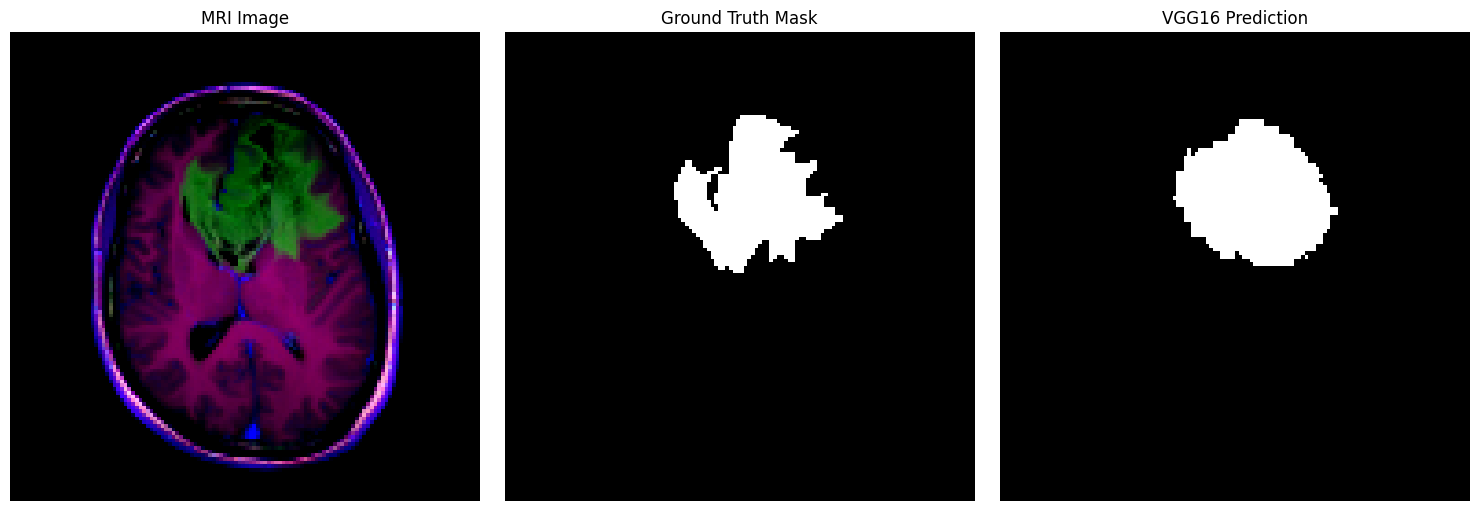

In [ ]:
# ============================================
# CELL 66: VGG16 Prediction Visualization
# ============================================

import random
import matplotlib.pyplot as plt

images, masks = next(iter(test_loader))

images_gpu = images.to(DEVICE)

with torch.no_grad():

    outputs = vgg16_model(images_gpu)

    probs = torch.sigmoid(outputs)

    preds = (probs > 0.5).float()


images = images.cpu()
masks = masks.cpu()
preds = preds.squeeze(1).cpu()


idx = random.randint(0, len(images) - 1)

image = images[idx]
mask = masks[idx]
prediction = preds[idx]


image_np = image.permute(1, 2, 0).numpy()

image_np = image_np * 0.5 + 0.5

image_np = image_np.clip(0, 1)


plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_np)
plt.title("MRI Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(prediction, cmap="gray")
plt.title("VGG16 Prediction")
plt.axis("off")

plt.tight_layout()
plt.show()

VGG16 + U-Net with skip connections

                 VGG16 Encoder
MRI ──────────────────────────────────┐
 ↓                                    │
64 × 128×128 ────────────────────────┐ │
 ↓                                   │ │
128 × 64×64 ───────────────────────┐ │ │
 ↓                                 │ │ │
256 × 32×32 ─────────────────────┐ │ │ │
 ↓                               │ │ │ │
512 × 16×16 ───────────────────┐ │ │ │ │
 ↓                             │ │ │ │ │
512 × 8×8                      │ │ │ │ │
 ↓                             │ │ │ │ │
          Decoder              │ │ │ │ │
             ↑                 │ │ │ │ │
             └── Skip ─────────┘ │ │ │ │
                ↑                │ │ │ │
                └── Skip ────────┘ │ │ │
                   ↑               │ │ │
                   └── Skip ───────┘ │ │
                      ↑              │ │
                      └── Skip ──────┘
                             
                         ↓
                    Tumor Mask
                   1 × 128 × 128

In [ ]:
#  67: VGG16 + U-Net


import torch
import torch.nn as nn
from torchvision.models import vgg16, VGG16_Weights


class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels):

        super().__init__()

        self.block = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(out_channels),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(out_channels),

            nn.ReLU(inplace=True)
        )

    def forward(self, x):

        return self.block(x)


class VGG16_UNet(nn.Module):

    def __init__(self, out_channels=1):

        super().__init__()

        # ====================================
        # PRETRAINED VGG16
        # ====================================

        vgg = vgg16(
            weights=VGG16_Weights.DEFAULT
        )

        features = vgg.features


        # ====================================
        # VGG16 ENCODER BLOCKS
        # ====================================

        self.enc1 = nn.Sequential(
            *features[0:4]
        )
        # Output: 64 channels


        self.enc2 = nn.Sequential(
            *features[5:9]
        )
        # Output: 128 channels


        self.enc3 = nn.Sequential(
            *features[10:16]
        )
        # Output: 256 channels


        self.enc4 = nn.Sequential(
            *features[17:23]
        )
        # Output: 512 channels


        self.enc5 = nn.Sequential(
            *features[24:30]
        )
        # Output: 512 channels


        # ====================================
        # POOLING
        # ====================================

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )


        # ====================================
        # BOTTLENECK
        # ====================================

        self.bottleneck = DoubleConv(
            512,
            512
        )


        # ====================================
        # DECODER 5
        # ====================================

        self.up5 = nn.ConvTranspose2d(
            512,
            512,
            kernel_size=2,
            stride=2
        )

        self.dec5 = DoubleConv(
            1024,
            512
        )


        # ====================================
        # DECODER 4
        # ====================================

        self.up4 = nn.ConvTranspose2d(
            512,
            256,
            kernel_size=2,
            stride=2
        )

        self.dec4 = DoubleConv(
            768,
            256
        )


        # ====================================
        # DECODER 3
        # ====================================

        self.up3 = nn.ConvTranspose2d(
            256,
            128,
            kernel_size=2,
            stride=2
        )

        self.dec3 = DoubleConv(
            384,
            128
        )


        # ====================================
        # DECODER 2
        # ====================================

        self.up2 = nn.ConvTranspose2d(
            128,
            64,
            kernel_size=2,
            stride=2
        )

        self.dec2 = DoubleConv(
            192,
            64
        )


        # ====================================
        # DECODER 1
        # ====================================

        self.up1 = nn.ConvTranspose2d(
            64,
            32,
            kernel_size=2,
            stride=2
        )

        self.dec1 = DoubleConv(
            96,
            32
        )


        # ====================================
        # FINAL SEGMENTATION HEAD
        # ====================================

        self.final = nn.Conv2d(
            32,
            out_channels,
            kernel_size=1
        )


    def forward(self, x):

        # ====================================
        # ENCODER
        # ====================================

        e1 = self.enc1(x)
        p1 = self.pool(e1)

        e2 = self.enc2(p1)
        p2 = self.pool(e2)

        e3 = self.enc3(p2)
        p3 = self.pool(e3)

        e4 = self.enc4(p3)
        p4 = self.pool(e4)

        e5 = self.enc5(p4)
        p5 = self.pool(e5)


        # ====================================
        # BOTTLENECK
        # ====================================

        b = self.bottleneck(p5)


        # ====================================
        # DECODER + SKIP CONNECTIONS
        # ====================================

        d5 = self.up5(b)

        d5 = torch.cat(
            [d5, e5],
            dim=1
        )

        d5 = self.dec5(d5)


        d4 = self.up4(d5)

        d4 = torch.cat(
            [d4, e4],
            dim=1
        )

        d4 = self.dec4(d4)


        d3 = self.up3(d4)

        d3 = torch.cat(
            [d3, e3],
            dim=1
        )

        d3 = self.dec3(d3)


        d2 = self.up2(d3)

        d2 = torch.cat(
            [d2, e2],
            dim=1
        )

        d2 = self.dec2(d2)


        d1 = self.up1(d2)

        d1 = torch.cat(
            [d1, e1],
            dim=1
        )

        d1 = self.dec1(d1)


        # ====================================
        # OUTPUT
        # ====================================

        out = self.final(d1)

        return out

In [ ]:
#  Create VGG16 + U-Net


vgg16_unet = VGG16_UNet(
    out_channels=1
)

vgg16_unet = vgg16_unet.to(DEVICE)

print("VGG16 + U-Net created successfully!")

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 76.7MB/s]


VGG16 + U-Net created successfully!


In [ ]:
#  69: Parameter Count

total_params = sum(
    p.numel()
    for p in vgg16_unet.parameters()
)

trainable_params = sum(
    p.numel()
    for p in vgg16_unet.parameters()
    if p.requires_grad
)

print(
    "Total parameters    :",
    f"{total_params:,}"
)

print(
    "Trainable parameters:",
    f"{trainable_params:,}"
)

Total parameters    : 31,399,553
Trainable parameters: 31,399,553


In [ ]:
# 70: Forward Pass Test


images, masks = next(iter(train_loader))

images = images.to(DEVICE)
masks = masks.to(DEVICE)

with torch.no_grad():

    outputs = vgg16_unet(images)

print("Input shape :", images.shape)
print("Output shape:", outputs.shape)
print("Target shape:", masks.shape)

Input shape : torch.Size([4, 3, 128, 128])
Output shape: torch.Size([4, 1, 128, 128])
Target shape: torch.Size([4, 128, 128])


In [ ]:
#  VGG16 + U-Net Loss & Optimizer


vgg16_unet_criterion = BCEDiceLoss(
    bce_weight=0.5,
    dice_weight=0.5
)

vgg16_unet_optimizer = torch.optim.Adam(
    vgg16_unet.parameters(),
    lr=LEARNING_RATE
)

print("Model        : VGG16 + U-Net")
print("Loss         : BCE + Dice")
print("Optimizer    : Adam")
print("Learning rate:", LEARNING_RATE)

Model        : VGG16 + U-Net
Loss         : BCE + Dice
Optimizer    : Adam
Learning rate: 0.0001


In [ ]:
#  VGG16 + U-Net Smoke Test

VGG16_UNET_SMOKE_EPOCHS = 3

vgg16_unet_best_smoke_dice = -1.0

for epoch in range(1, VGG16_UNET_SMOKE_EPOCHS + 1):

    train_loss, train_dice, train_iou = train_one_epoch(
        vgg16_unet,
        train_loader,
        vgg16_unet_criterion,
        vgg16_unet_optimizer,
        DEVICE
    )

    val_loss, val_dice, val_iou = validate_one_epoch(
        vgg16_unet,
        val_loader,
        vgg16_unet_criterion,
        DEVICE
    )

    print(f"\nEpoch [{epoch}/{VGG16_UNET_SMOKE_EPOCHS}]")

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Dice: {train_dice:.4f} | "
        f"IoU: {train_iou:.4f}"
    )

    print(
        f"Val Loss:   {val_loss:.4f} | "
        f"Dice: {val_dice:.4f} | "
        f"IoU: {val_iou:.4f}"
    )

    print("-" * 60)

    if val_dice > vgg16_unet_best_smoke_dice:

        vgg16_unet_best_smoke_dice = val_dice

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": vgg16_unet.state_dict(),
                "optimizer_state_dict": vgg16_unet_optimizer.state_dict(),
                "val_dice": val_dice,
                "val_iou": val_iou,
                "val_loss": val_loss
            },
            "/content/drive/MyDrive/labledataset/"
            "vgg16_unet_smoke_best.pth"
        )

        print("✓ Best VGG16 + U-Net smoke-test model saved!")


Epoch [1/3]
Train Loss: 0.6712 | Dice: 0.5189 | IoU: 0.4816
Val Loss:   0.5852 | Dice: 0.7422 | IoU: 0.7000
------------------------------------------------------------
✓ Best VGG16 + U-Net smoke-test model saved!

Epoch [2/3]
Train Loss: 0.5317 | Dice: 0.8071 | IoU: 0.7705
Val Loss:   0.4925 | Dice: 0.8838 | IoU: 0.8497
------------------------------------------------------------
✓ Best VGG16 + U-Net smoke-test model saved!

Epoch [3/3]
Train Loss: 0.4550 | Dice: 0.7904 | IoU: 0.7558
Val Loss:   0.4343 | Dice: 0.8942 | IoU: 0.8610
------------------------------------------------------------
✓ Best VGG16 + U-Net smoke-test model saved!


In [ ]:
#  73: Fresh VGG16 + U-Net for Final Training


# Create a fresh model
vgg16_unet = VGG16_UNet(
    out_channels=1
).to(DEVICE)

# Loss
vgg16_unet_criterion = BCEDiceLoss(
    bce_weight=0.5,
    dice_weight=0.5
)

# Optimizer
vgg16_unet_optimizer = torch.optim.Adam(
    vgg16_unet.parameters(),
    lr=LEARNING_RATE
)

print("Fresh VGG16 + U-Net model created!")
print("Starting final training from pretrained VGG16 weights.")

Fresh VGG16 + U-Net model created!
Starting final training from pretrained VGG16 weights.


In [ ]:
#Final VGG16 + U-Net Training


VGG16_UNET_MAX_EPOCHS = 30
VGG16_UNET_PATIENCE = 7

VGG16_UNET_BEST_MODEL_PATH = (
    "/content/drive/MyDrive/labledataset/"
    "vgg16_unet_best.pth"
)

train_history_vu = {
    "loss": [],
    "dice": [],
    "iou": []
}

val_history_vu = {
    "loss": [],
    "dice": [],
    "iou": []
}

best_vu_val_dice = -1.0
vu_patience_counter = 0


for epoch in range(1, VGG16_UNET_MAX_EPOCHS + 1):

    # -----------------------------
    # Training
    # -----------------------------

    train_loss, train_dice, train_iou = train_one_epoch(
        vgg16_unet,
        train_loader,
        vgg16_unet_criterion,
        vgg16_unet_optimizer,
        DEVICE
    )

    # -----------------------------
    # Validation
    # -----------------------------

    val_loss, val_dice, val_iou = validate_one_epoch(
        vgg16_unet,
        val_loader,
        vgg16_unet_criterion,
        DEVICE
    )

    # Save history
    train_history_vu["loss"].append(train_loss)
    train_history_vu["dice"].append(train_dice)
    train_history_vu["iou"].append(train_iou)

    val_history_vu["loss"].append(val_loss)
    val_history_vu["dice"].append(val_dice)
    val_history_vu["iou"].append(val_iou)

    # -----------------------------
    # Print
    # -----------------------------

    print(f"\nEpoch [{epoch}/{VGG16_UNET_MAX_EPOCHS}]")

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Dice: {train_dice:.4f} | "
        f"IoU: {train_iou:.4f}"
    )

    print(
        f"Val Loss:   {val_loss:.4f} | "
        f"Dice: {val_dice:.4f} | "
        f"IoU: {val_iou:.4f}"
    )

    # -----------------------------
    # Best model
    # -----------------------------

    if val_dice > best_vu_val_dice:

        best_vu_val_dice = val_dice
        vu_patience_counter = 0

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict":
                    vgg16_unet.state_dict(),
                "optimizer_state_dict":
                    vgg16_unet_optimizer.state_dict(),
                "best_val_dice":
                    best_vu_val_dice,
                "val_iou":
                    val_iou,
                "val_loss":
                    val_loss
            },
            VGG16_UNET_BEST_MODEL_PATH
        )

        print(
            f"✓ Best VGG16 + U-Net model saved! "
            f"Val Dice = {best_vu_val_dice:.4f}"
        )

    else:

        vu_patience_counter += 1

        print(
            f"No improvement "
            f"({vu_patience_counter}/{VGG16_UNET_PATIENCE})"
        )

    # -----------------------------
    # Early stopping
    # -----------------------------

    if vu_patience_counter >= VGG16_UNET_PATIENCE:

        print("\nEarly stopping triggered.")

        print(
            "Best Validation Dice:",
            f"{best_vu_val_dice:.4f}"
        )

        break


print("\n============================================")
print("VGG16 + U-Net training completed!")
print(
    "Best Validation Dice:",
    f"{best_vu_val_dice:.4f}"
)
print("============================================")


Epoch [1/30]
Train Loss: 0.6699 | Dice: 0.4402 | IoU: 0.4024
Val Loss:   0.5855 | Dice: 0.8643 | IoU: 0.8274
✓ Best VGG16 + U-Net model saved! Val Dice = 0.8643

Epoch [2/30]
Train Loss: 0.5379 | Dice: 0.7542 | IoU: 0.7166
Val Loss:   0.4950 | Dice: 0.8557 | IoU: 0.8203
No improvement (1/7)

Epoch [3/30]
Train Loss: 0.4585 | Dice: 0.7901 | IoU: 0.7558
Val Loss:   0.4306 | Dice: 0.8482 | IoU: 0.8144
No improvement (2/7)

Epoch [4/30]
Train Loss: 0.4149 | Dice: 0.8088 | IoU: 0.7752
Val Loss:   0.4006 | Dice: 0.7770 | IoU: 0.7433
No improvement (3/7)

Epoch [5/30]
Train Loss: 0.3899 | Dice: 0.8023 | IoU: 0.7698
Val Loss:   0.3879 | Dice: 0.8715 | IoU: 0.8383
✓ Best VGG16 + U-Net model saved! Val Dice = 0.8715

Epoch [6/30]
Train Loss: 0.3772 | Dice: 0.8183 | IoU: 0.7863
Val Loss:   0.3703 | Dice: 0.7496 | IoU: 0.7151
No improvement (1/7)

Epoch [7/30]
Train Loss: 0.3709 | Dice: 0.7614 | IoU: 0.7295
Val Loss:   0.3705 | Dice: 0.8768 | IoU: 0.8439
✓ Best VGG16 + U-Net model saved! Val Dice

In [ ]:
#  75: Load Best VGG16 + U-Net Model


checkpoint = torch.load(
    "/content/drive/MyDrive/labledataset/vgg16_unet_best.pth",
    map_location=DEVICE
)

vgg16_unet.load_state_dict(
    checkpoint["model_state_dict"]
)

vgg16_unet.eval()

print("Best VGG16 + U-Net model loaded successfully!")
print("Best epoch:", checkpoint["epoch"])
print("Best Val Dice:", checkpoint["best_val_dice"])
print("Best Val IoU :", checkpoint["val_iou"])

Best VGG16 + U-Net model loaded successfully!
Best epoch: 12
Best Val Dice: 0.8948966711759567
Best Val IoU : 0.8643087807136614


In [ ]:
# ============================================
# VGG16 + U-NET FINAL TEST EVALUATION
# ============================================

def evaluate_model(model, loader, criterion, device):

    model.eval()

    total_loss = 0.0
    total_dice = 0.0
    total_iou = 0.0
    num_batches = 0

    with torch.no_grad():

        for images, masks in loader:

            images = images.to(device)
            masks = masks.to(device)

            # Add channel dimension
            # [B, H, W] -> [B, 1, H, W]
            masks_for_loss = masks.unsqueeze(1)

            # Prediction
            outputs = model(images)

            # Loss
            loss = criterion(
                outputs,
                masks_for_loss
            )

            # Probability
            probs = torch.sigmoid(outputs)

            # Binary prediction
            preds = (probs > 0.5).float()

            # Remove channel dimension for metrics
            preds_flat = preds.squeeze(1).view(
                preds.size(0), -1
            )

            masks_flat = masks.view(
                masks.size(0), -1
            )

            # Intersection
            intersection = (
                preds_flat * masks_flat
            ).sum(dim=1)

            # Dice
            dice = (
                (2 * intersection + 1e-7) /
                (
                    preds_flat.sum(dim=1)
                    + masks_flat.sum(dim=1)
                    + 1e-7
                )
            ).mean()

            # Union
            union = (
                preds_flat.sum(dim=1)
                + masks_flat.sum(dim=1)
                - intersection
            )

            # IoU
            iou = (
                (intersection + 1e-7) /
                (union + 1e-7)
            ).mean()

            total_loss += loss.item()
            total_dice += dice.item()
            total_iou += iou.item()

            num_batches += 1

    return (
        total_loss / num_batches,
        total_dice / num_batches,
        total_iou / num_batches
    )


# ============================================
# RUN TEST
# ============================================

test_loss, test_dice, test_iou = evaluate_model(
    vgg16_unet,
    test_loader,
    vgg16_unet_criterion,
    DEVICE
)

print("=" * 60)
print("VGG16 + U-NET TEST RESULTS")
print("=" * 60)

print(f"Test Loss : {test_loss:.4f}")
print(f"Test Dice : {test_dice:.4f}")
print(f"Test IoU  : {test_iou:.4f}")

print("=" * 60)

VGG16 + U-NET TEST RESULTS
Test Loss : 0.3639
Test Dice : 0.9117
Test IoU  : 0.8847


In [ ]:
# VGG16 + U-NET: PRECISION, RECALL, ACCURACY


def calculate_segmentation_metrics(model, loader, device):

    model.eval()

    total_tp = 0
    total_fp = 0
    total_fn = 0
    total_tn = 0

    with torch.no_grad():

        for images, masks in loader:

            images = images.to(device)
            masks = masks.to(device)

            # [B,H,W] -> [B,1,H,W]
            masks = masks.unsqueeze(1)

            # Prediction
            outputs = model(images)
            probs = torch.sigmoid(outputs)

            preds = (probs > 0.5).float()

            # Flatten
            preds = preds.view(-1)
            masks = masks.view(-1)

            # Confusion matrix components
            tp = ((preds == 1) & (masks == 1)).sum().item()
            fp = ((preds == 1) & (masks == 0)).sum().item()
            fn = ((preds == 0) & (masks == 1)).sum().item()
            tn = ((preds == 0) & (masks == 0)).sum().item()

            total_tp += tp
            total_fp += fp
            total_fn += fn
            total_tn += tn

    # Metrics
    precision = total_tp / (
        total_tp + total_fp + 1e-7
    )

    recall = total_tp / (
        total_tp + total_fn + 1e-7
    )

    accuracy = (
        total_tp + total_tn
    ) / (
        total_tp + total_tn +
        total_fp + total_fn + 1e-7
    )

    return precision, recall, accuracy


# ============================================
# RUN METRICS
# ============================================

precision_vu, recall_vu, accuracy_vu = (
    calculate_segmentation_metrics(
        vgg16_unet,
        test_loader,
        DEVICE
    )
)

print("=" * 60)
print("VGG16 + U-NET FINAL TEST METRICS")
print("=" * 60)

print(f"Dice      : {test_dice:.4f}")
print(f"IoU       : {test_iou:.4f}")
print(f"Precision : {precision_vu:.4f}")
print(f"Recall    : {recall_vu:.4f}")
print(f"Accuracy  : {accuracy_vu:.4f}")

print("=" * 60)

VGG16 + U-NET FINAL TEST METRICS
Dice      : 0.9117
IoU       : 0.8847
Precision : 0.9123
Recall    : 0.8877
Accuracy  : 0.9980


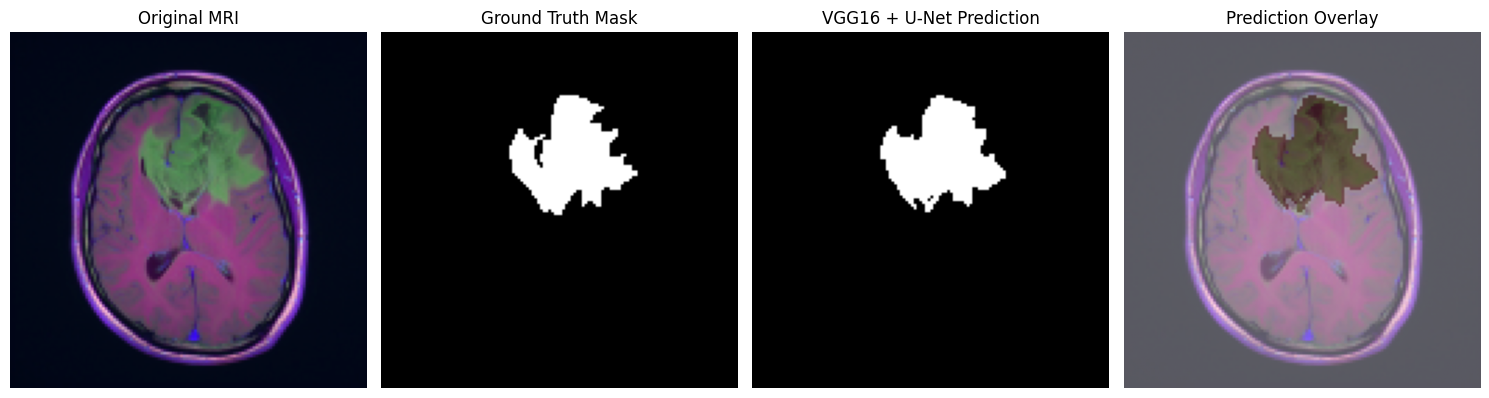

In [ ]:

#  VGG16 + U-Net Prediction Visualization


import matplotlib.pyplot as plt
import numpy as np

vgg16_unet.eval()

# one test sample
images, masks = next(iter(test_loader))

image = images[0].to(DEVICE)
true_mask = masks[0].cpu().numpy()

with torch.no_grad():

    output = vgg16_unet(
        image.unsqueeze(0)
    )

    probability = torch.sigmoid(output)

    prediction = (
        probability > 0.5
    ).float()

pred_mask = prediction.squeeze().cpu().numpy()

# Original image
original = image.cpu().numpy()

# CHW -> HWC
original = np.transpose(
    original,
    (1, 2, 0)
)

# Normalize for visualization
original = (
    original - original.min()
) / (
    original.max() - original.min() + 1e-8
)


# PLOT


plt.figure(figsize=(15, 4))

plt.subplot(1, 4, 1)
plt.imshow(original)
plt.title("Original MRI")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(true_mask, cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(pred_mask, cmap="gray")
plt.title("VGG16 + U-Net Prediction")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(original)
plt.imshow(
    pred_mask,
    cmap="Reds",
    alpha=0.35
)
plt.title("Prediction Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Check available PyTorch models safely

model_names = []

for name, obj in list(globals().items()):
    if isinstance(obj, torch.nn.Module):
        model_names.append((name, type(obj).__name__))

for name, model_type in model_names:
    print(name, "->", model_type)

vanilla_unet -> VanillaUNet
criterion -> BCEDiceLoss
vgg16_model -> VGG16Segmentation
vgg16_criterion -> BCEDiceLoss
vgg16_unet -> VGG16_UNet
vgg16_unet_criterion -> BCEDiceLoss


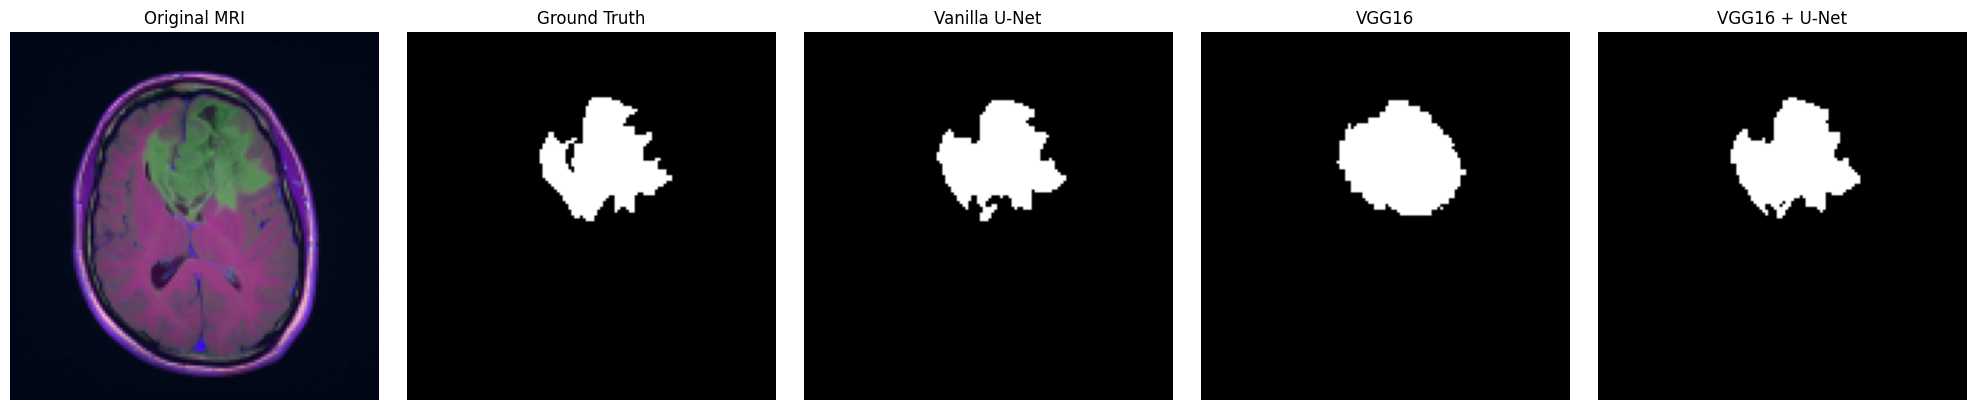

In [ ]:

# THREE-MODEL VISUAL COMPARISON


import matplotlib.pyplot as plt
import numpy as np
import torch


# ------------------------------------------------------------
# Get one test sample
# ------------------------------------------------------------

images, masks = next(iter(test_loader))

image = images[0].to(DEVICE)
true_mask = masks[0].cpu().numpy()


# ------------------------------------------------------------
# Prediction Function
# ------------------------------------------------------------

def get_prediction(model, image):

    model.eval()

    with torch.no_grad():

        output = model(image.unsqueeze(0))

        probability = torch.sigmoid(output)

        prediction = (probability > 0.5).float()

    return prediction.squeeze().cpu().numpy()


# ------------------------------------------------------------
# Get predictions
# ------------------------------------------------------------

vanilla_unet_prediction = get_prediction(
    vanilla_unet,
    image
)

vgg16_prediction = get_prediction(
    vgg16_model,
    image
)

vgg16_unet_prediction = get_prediction(
    vgg16_unet,
    image
)


# ------------------------------------------------------------
# Prepare Original MRI
# ------------------------------------------------------------

original = image.cpu().numpy()

original = np.transpose(
    original,
    (1, 2, 0)
)

original = (
    original - original.min()
) / (
    original.max() - original.min() + 1e-8
)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(20, 4))


# 1. Original MRI
plt.subplot(1, 5, 1)

plt.imshow(original)

plt.title("Original MRI")

plt.axis("off")


# 2. Ground Truth
plt.subplot(1, 5, 2)

plt.imshow(true_mask, cmap="gray")

plt.title("Ground Truth")

plt.axis("off")


# 3. Vanilla U-Net
plt.subplot(1, 5, 3)

plt.imshow(vanilla_unet_prediction, cmap="gray")

plt.title("Vanilla U-Net")

plt.axis("off")


# 4. VGG16
plt.subplot(1, 5, 4)

plt.imshow(vgg16_prediction, cmap="gray")

plt.title("VGG16")

plt.axis("off")


# 5. VGG16 + U-Net
plt.subplot(1, 5, 5)

plt.imshow(vgg16_unet_prediction, cmap="gray")

plt.title("VGG16 + U-Net")

plt.axis("off")


plt.tight_layout()

plt.show()

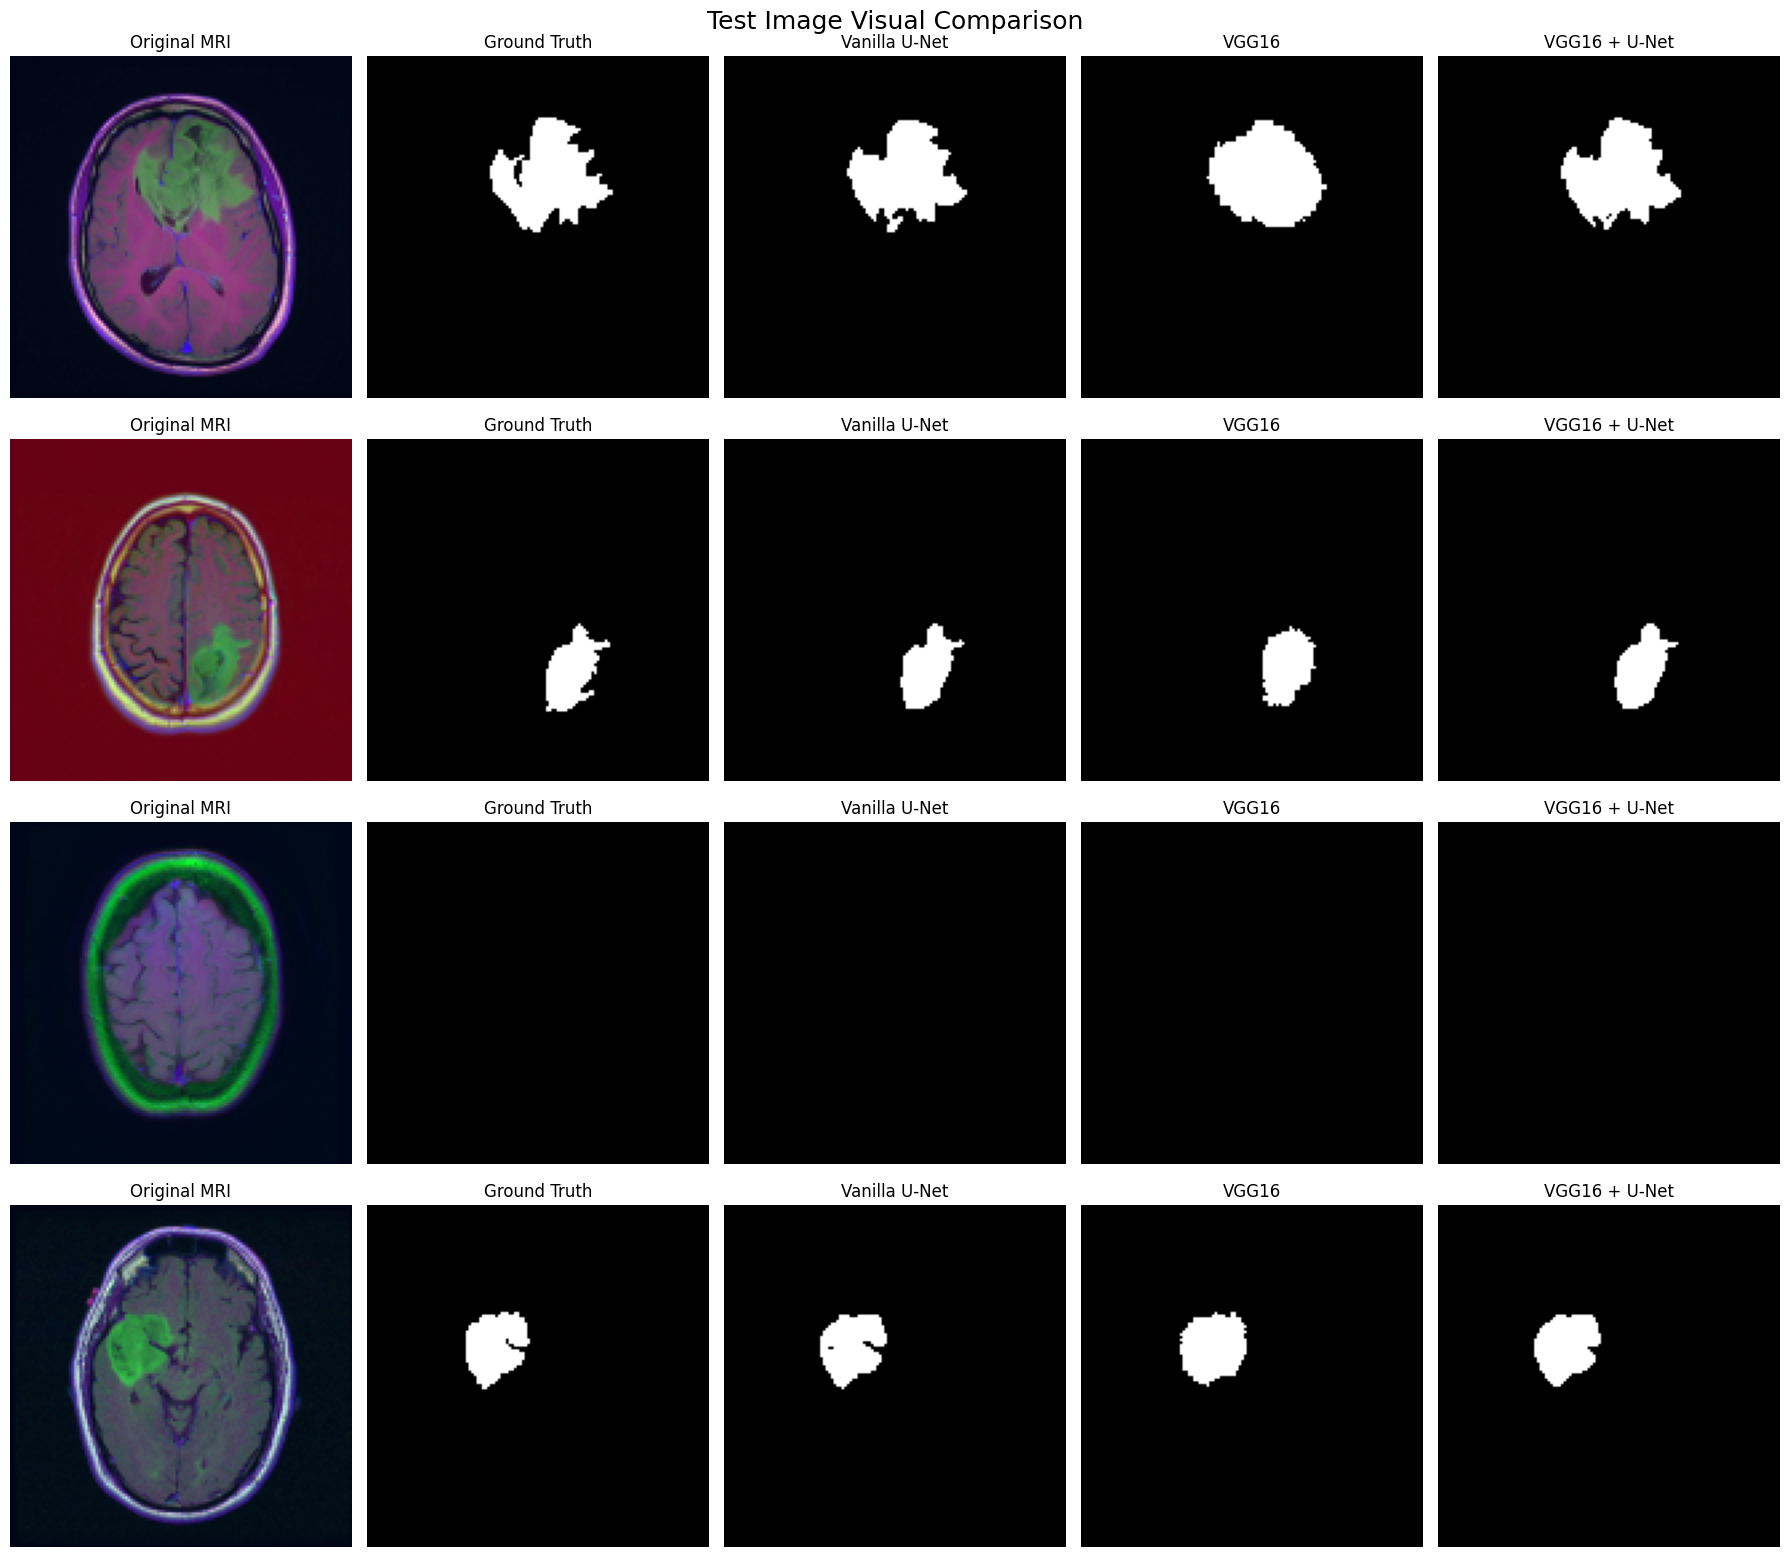

In [ ]:
# ============================================================
# TEST IMAGES - THREE MODEL VISUAL COMPARISON
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import torch


# ------------------------------------------------------------
# Prediction Function
# ------------------------------------------------------------

def get_prediction(model, image):

    model.eval()

    with torch.no_grad():

        output = model(image.unsqueeze(0))

        probability = torch.sigmoid(output)

        prediction = (probability > 0.5).float()

    return prediction.squeeze().cpu().numpy()


# ------------------------------------------------------------
# Get Test Batch
# ------------------------------------------------------------

images, masks = next(iter(test_loader))

# Automatically use available images
num_images = min(4, images.shape[0])


# ------------------------------------------------------------
# Create Figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    num_images,
    5,
    figsize=(18, 4 * num_images)
)


# ------------------------------------------------------------
# Process Images
# ------------------------------------------------------------

for i in range(num_images):

    image = images[i].to(DEVICE)

    true_mask = masks[i].cpu().numpy()


    # --------------------------------------------------------
    # Predictions
    # --------------------------------------------------------

    vanilla_prediction = get_prediction(
        vanilla_unet,
        image
    )

    vgg16_prediction = get_prediction(
        vgg16_model,
        image
    )

    vgg16_unet_prediction = get_prediction(
        vgg16_unet,
        image
    )


    # --------------------------------------------------------
    # Original MRI
    # --------------------------------------------------------

    original = image.cpu().numpy()

    original = np.transpose(
        original,
        (1, 2, 0)
    )

    original = (
        original - original.min()
    ) / (
        original.max() - original.min() + 1e-8
    )


    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    axes[i, 0].imshow(original)
    axes[i, 0].set_title("Original MRI")
    axes[i, 0].axis("off")


    axes[i, 1].imshow(
        true_mask,
        cmap="gray"
    )

    axes[i, 1].set_title("Ground Truth")
    axes[i, 1].axis("off")


    axes[i, 2].imshow(
        vanilla_prediction,
        cmap="gray"
    )

    axes[i, 2].set_title("Vanilla U-Net")
    axes[i, 2].axis("off")


    axes[i, 3].imshow(
        vgg16_prediction,
        cmap="gray"
    )

    axes[i, 3].set_title("VGG16")
    axes[i, 3].axis("off")


    axes[i, 4].imshow(
        vgg16_unet_prediction,
        cmap="gray"
    )

    axes[i, 4].set_title("VGG16 + U-Net")
    axes[i, 4].axis("off")


plt.suptitle(
    "Test Image Visual Comparison",
    fontsize=18
)

plt.tight_layout()

plt.show()

In [ ]:
# FINAL TEST METRICS - THREE MODEL COMPARISON

import torch
import numpy as np


# Metric Functions

def calculate_metrics(model, loader, device):

    model.eval()

    total_dice = 0.0
    total_iou = 0.0
    total_precision = 0.0
    total_recall = 0.0
    total_accuracy = 0.0

    total_samples = 0

    with torch.no_grad():

        for images, masks in loader:

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            probabilities = torch.sigmoid(outputs)

            predictions = (probabilities > 0.5).float()


            # Flatten
            predictions = predictions.view(predictions.size(0), -1)
            masks_flat = masks.view(masks.size(0), -1)


            # Convert to float
            predictions = predictions.float()
            masks_flat = masks_flat.float()


             # Calculate for each image

            for pred, true in zip(predictions, masks_flat):

                TP = (pred * true).sum()
                FP = (pred * (1 - true)).sum()
                FN = ((1 - pred) * true).sum()
                TN = ((1 - pred) * (1 - true)).sum()


                # Dice
                dice = (
                    (2 * TP + 1e-8) /
                    (2 * TP + FP + FN + 1e-8)
                )


                # IoU
                iou = (
                    (TP + 1e-8) /
                    (TP + FP + FN + 1e-8)
                )


                # Precision
                precision = (
                    (TP + 1e-8) /
                    (TP + FP + 1e-8)
                )


                # Recall
                recall = (
                    (TP + 1e-8) /
                    (TP + FN + 1e-8)
                )


                # Accuracy
                accuracy = (
                    (TP + TN + 1e-8) /
                    (TP + TN + FP + FN + 1e-8)
                )


                total_dice += dice.item()
                total_iou += iou.item()
                total_precision += precision.item()
                total_recall += recall.item()
                total_accuracy += accuracy.item()

                total_samples += 1


    # Average metrics

    return {
        "Dice": total_dice / total_samples,
        "IoU": total_iou / total_samples,
        "Precision": total_precision / total_samples,
        "Recall": total_recall / total_samples,
        "Accuracy": total_accuracy / total_samples
    }



# Evaluate Vanilla U-Net


print("Evaluating Vanilla U-Net...")

vanilla_metrics = calculate_metrics(
    vanilla_unet,
    test_loader,
    DEVICE
)


# Evaluate VGG16


print("Evaluating VGG16...")

vgg16_metrics = calculate_metrics(
    vgg16_model,
    test_loader,
    DEVICE
)



# Evaluate VGG16 + U-Net


print("Evaluating VGG16 + U-Net...")

vgg16_unet_metrics = calculate_metrics(
    vgg16_unet,
    test_loader,
    DEVICE
)



# Print Results


print("\n")
print("=" * 70)
print("FINAL THREE-MODEL TEST METRICS")
print("=" * 70)


print("\nVanilla U-Net")
print("-" * 30)

for metric, value in vanilla_metrics.items():
    print(f"{metric:<12}: {value:.4f}")


print("\nVGG16")
print("-" * 30)

for metric, value in vgg16_metrics.items():
    print(f"{metric:<12}: {value:.4f}")


print("\nVGG16 + U-Net")
print("-" * 30)

for metric, value in vgg16_unet_metrics.items():
    print(f"{metric:<12}: {value:.4f}")


print("\n")
print("=" * 70)

Evaluating Vanilla U-Net...
Evaluating VGG16...
Evaluating VGG16 + U-Net...


FINAL THREE-MODEL TEST METRICS

Vanilla U-Net
------------------------------
Dice        : 0.8033
IoU         : 0.7723
Precision   : 0.8281
Recall      : 0.9329
Accuracy    : 0.9969

VGG16
------------------------------
Dice        : 0.8987
IoU         : 0.8601
Precision   : 0.9097
Recall      : 0.9273
Accuracy    : 0.9965

VGG16 + U-Net
------------------------------
Dice        : 0.9124
IoU         : 0.8856
Precision   : 0.9426
Recall      : 0.9343
Accuracy    : 0.9980




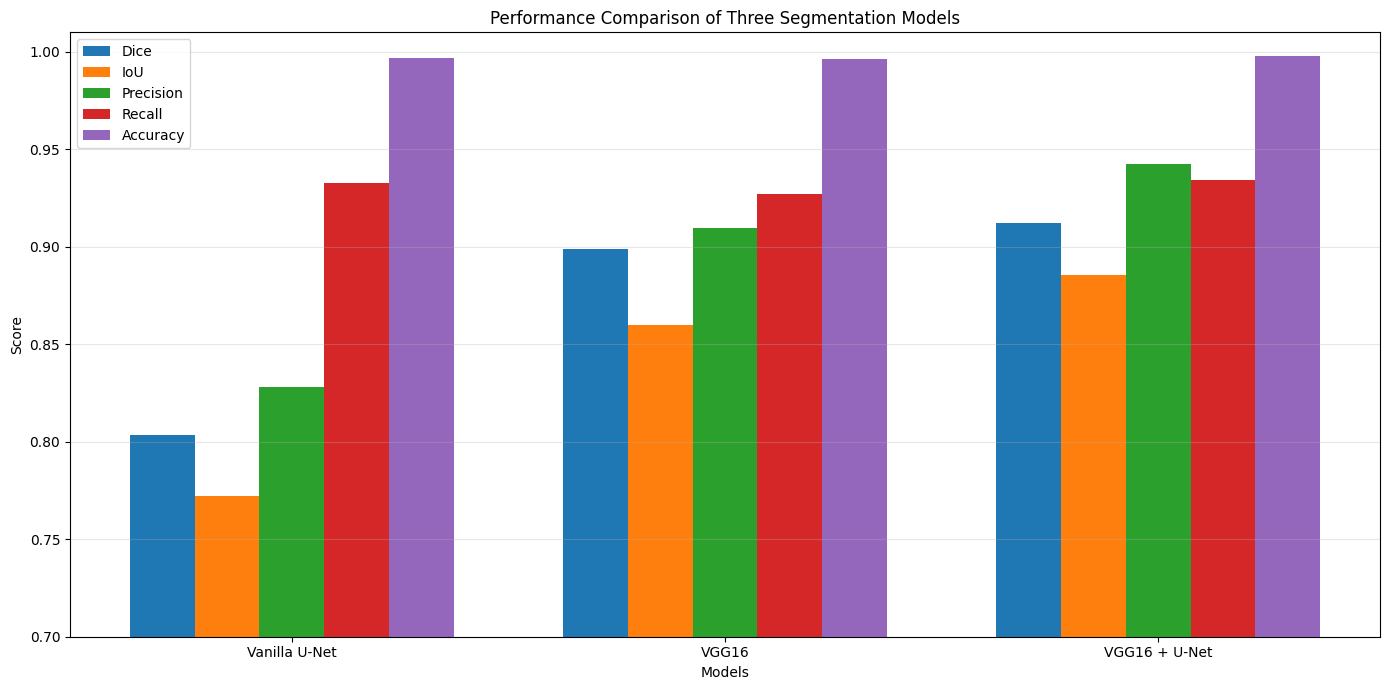

In [ ]:

# THREE-MODEL PERFORMANCE COMPARISON


import matplotlib.pyplot as plt
import numpy as np


# Model Names


models = [
    "Vanilla U-Net",
    "VGG16",
    "VGG16 + U-Net"
]



# Metric Values


dice = [
    vanilla_metrics["Dice"],
    vgg16_metrics["Dice"],
    vgg16_unet_metrics["Dice"]
]

iou = [
    vanilla_metrics["IoU"],
    vgg16_metrics["IoU"],
    vgg16_unet_metrics["IoU"]
]

precision = [
    vanilla_metrics["Precision"],
    vgg16_metrics["Precision"],
    vgg16_unet_metrics["Precision"]
]

recall = [
    vanilla_metrics["Recall"],
    vgg16_metrics["Recall"],
    vgg16_unet_metrics["Recall"]
]

accuracy = [
    vanilla_metrics["Accuracy"],
    vgg16_metrics["Accuracy"],
    vgg16_unet_metrics["Accuracy"]
]



# Create Comparison Plot


x = np.arange(len(models))

width = 0.15

plt.figure(figsize=(14, 7))

plt.bar(
    x - 2 * width,
    dice,
    width,
    label="Dice"
)

plt.bar(
    x - width,
    iou,
    width,
    label="IoU"
)

plt.bar(
    x,
    precision,
    width,
    label="Precision"
)

plt.bar(
    x + width,
    recall,
    width,
    label="Recall"
)

plt.bar(
    x + 2 * width,
    accuracy,
    width,
    label="Accuracy"
)



# Labels


plt.xlabel("Models")

plt.ylabel("Score")

plt.title(
    "Performance Comparison of Three Segmentation Models"
)

plt.xticks(
    x,
    models
)

plt.ylim(0.70, 1.01)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

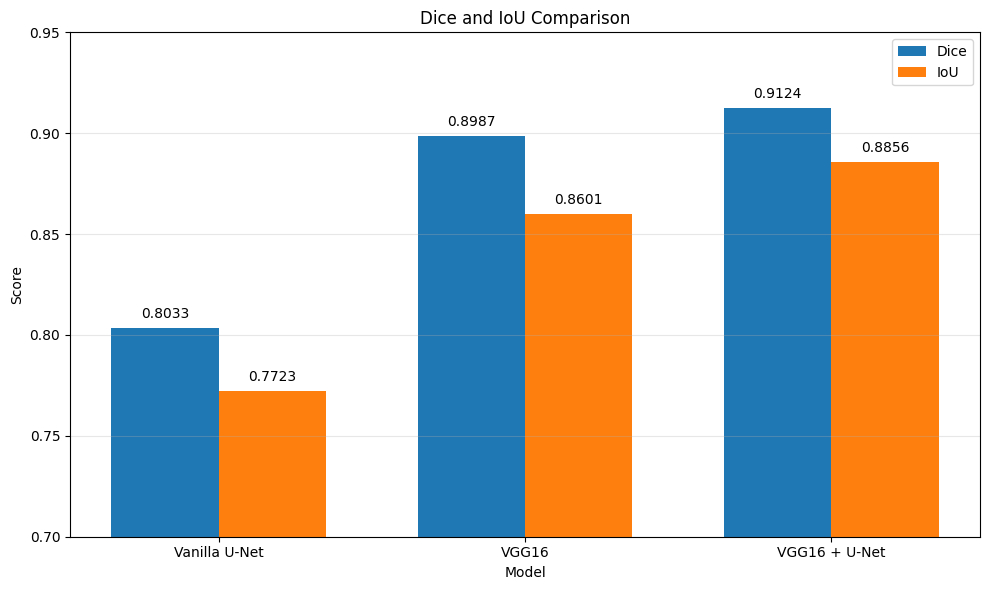

In [ ]:

# DICE AND IoU COMPARISON




models = [
    "Vanilla U-Net",
    "VGG16",
    "VGG16 + U-Net"
]

dice_scores = [
    vanilla_metrics["Dice"],
    vgg16_metrics["Dice"],
    vgg16_unet_metrics["Dice"]
]

iou_scores = [
    vanilla_metrics["IoU"],
    vgg16_metrics["IoU"],
    vgg16_unet_metrics["IoU"]
]

x = np.arange(len(models))
width = 0.35



# Create Plot


plt.figure(figsize=(10, 6))

bars1 = plt.bar(
    x - width/2,
    dice_scores,
    width,
    label="Dice"
)

bars2 = plt.bar(
    x + width/2,
    iou_scores,
    width,
    label="IoU"
)


# Add Values on Bars

for bar in bars1:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.005,
        f"{height:.4f}",
        ha="center",
        fontsize=10
    )


for bar in bars2:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.005,
        f"{height:.4f}",
        ha="center",
        fontsize=10
    )


# Labels


plt.xlabel("Model")

plt.ylabel("Score")

plt.title(
    "Dice and IoU Comparison"
)

plt.xticks(
    x,
    models
)

plt.ylim(0.70, 0.95)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [ ]:
print([x for x in globals().keys() if "history" in x.lower()])

['train_history', 'val_history', 'vgg16_train_history', 'vgg16_val_history', 'train_history_vu', 'val_history_vu']


In [ ]:
print([
    x for x in globals().keys()
    if any(word in x.lower() for word in [
        "loss",
        "dice",
        "iou",
        "train",
        "val",
        "history"
    ])
])

['train_test_split', 'train_df', 'val_df', 'train_transform', 'val_test_transform', 'train_dataset', 'val_dataset', 'train_loader', 'val_loader', 'dice_score', 'iou_score', 'DiceLoss', 'BCEDiceLoss', 'trainable_params', 'train_one_epoch', 'validate_one_epoch', 'best_val_dice', 'train_loss', 'train_dice', 'train_iou', 'val_loss', 'val_dice', 'val_iou', 'train_history', 'val_history', 'test_loss', 'test_dice', 'test_iou', 'loss', 'dice', 'iou', 'vgg16_best_val_dice', 'vgg16_train_history', 'vgg16_val_history', 'best_vgg16_val_dice', 'vgg16_test_loss', 'vgg16_test_dice', 'vgg16_test_iou', 'vgg16_unet_best_smoke_dice', 'train_history_vu', 'val_history_vu', 'best_vu_val_dice', 'evaluate_model', 'value', 'dice_scores', 'iou_scores', 'unet_train_loss', 'unet_val_loss', 'vgg16_train_loss', 'vgg16_val_loss', 'vgg16_unet_train_loss', 'vgg16_unet_val_loss']


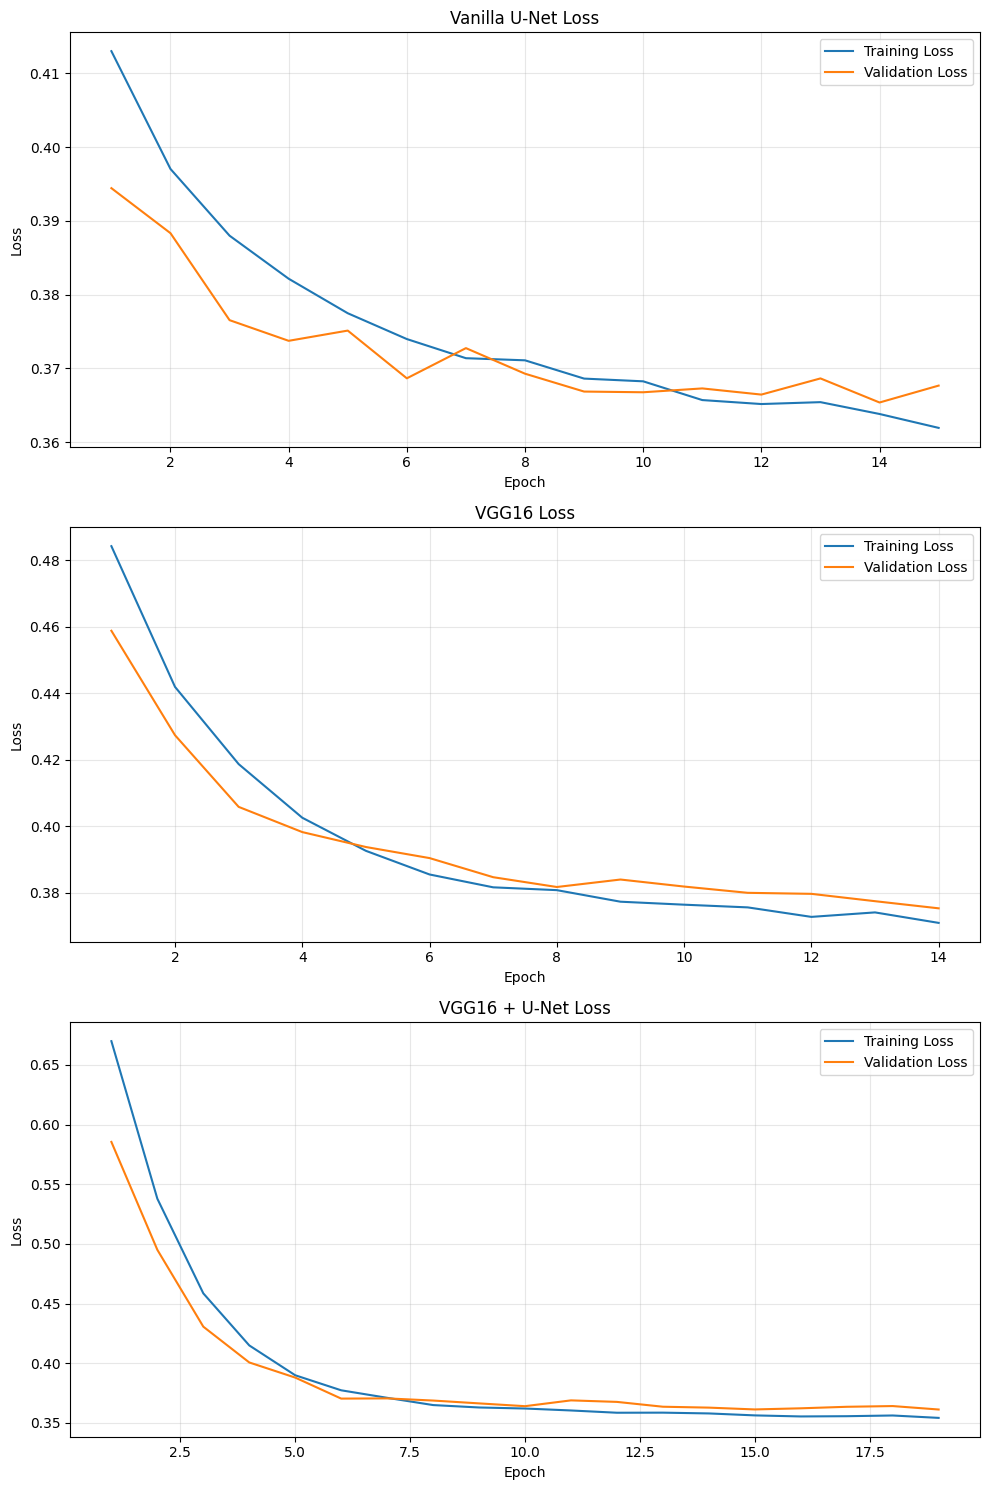

In [ ]:
import matplotlib.pyplot as plt

# Get loss history

unet_train_loss = train_history["loss"]
unet_val_loss = val_history["loss"]

vgg16_train_loss = vgg16_train_history["loss"]
vgg16_val_loss = vgg16_val_history["loss"]

vgg16_unet_train_loss = train_history_vu["loss"]
vgg16_unet_val_loss = val_history_vu["loss"]


# Create separate plots

fig, axes = plt.subplots(3, 1, figsize=(10, 15))


# Vanilla U-Net

axes[0].plot(
    range(1, len(unet_train_loss) + 1),
    unet_train_loss,
    label="Training Loss"
)

axes[0].plot(
    range(1, len(unet_val_loss) + 1),
    unet_val_loss,
    label="Validation Loss"
)

axes[0].set_title("Vanilla U-Net Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)


# VGG16

axes[1].plot(
    range(1, len(vgg16_train_loss) + 1),
    vgg16_train_loss,
    label="Training Loss"
)

axes[1].plot(
    range(1, len(vgg16_val_loss) + 1),
    vgg16_val_loss,
    label="Validation Loss"
)

axes[1].set_title("VGG16 Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)


# VGG16 + U-Net

axes[2].plot(
    range(1, len(vgg16_unet_train_loss) + 1),
    vgg16_unet_train_loss,
    label="Training Loss"
)

axes[2].plot(
    range(1, len(vgg16_unet_val_loss) + 1),
    vgg16_unet_val_loss,
    label="Validation Loss"
)

axes[2].set_title("VGG16 + U-Net Loss")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Loss")
axes[2].legend()
axes[2].grid(alpha=0.3)


plt.tight_layout()
plt.show()

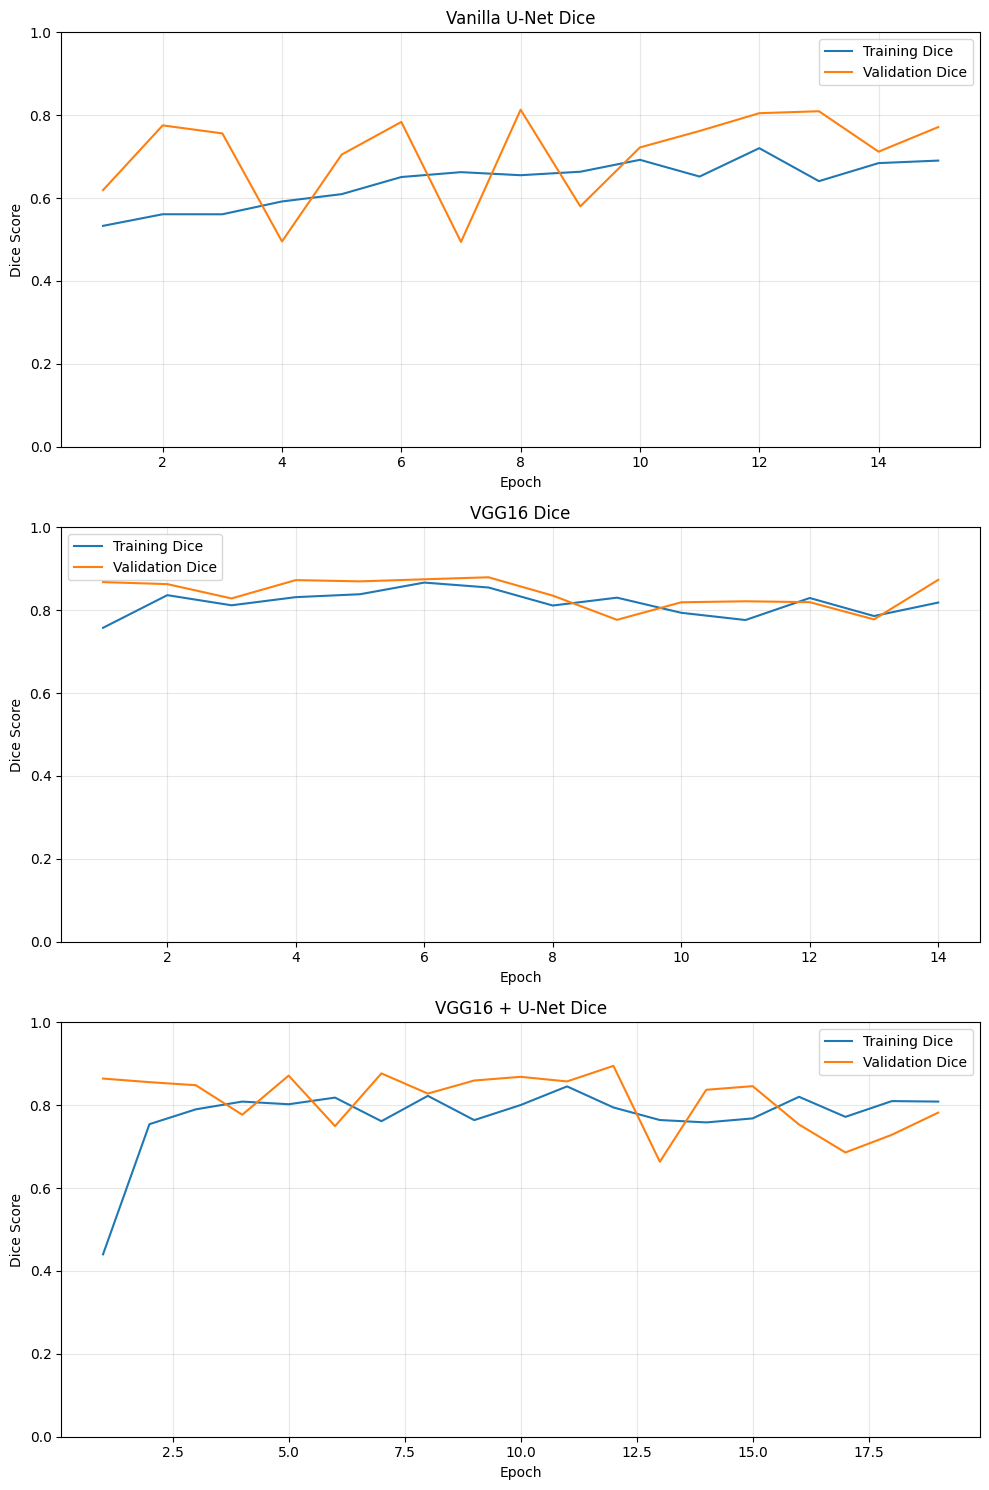

In [ ]:


# Get Dice history

unet_train_dice = train_history["dice"]
unet_val_dice = val_history["dice"]

vgg16_train_dice = vgg16_train_history["dice"]
vgg16_val_dice = vgg16_val_history["dice"]

vgg16_unet_train_dice = train_history_vu["dice"]
vgg16_unet_val_dice = val_history_vu["dice"]


# Create plots

fig, axes = plt.subplots(3, 1, figsize=(10, 15))


# Vanilla U-Net

axes[0].plot(
    range(1, len(unet_train_dice) + 1),
    unet_train_dice,
    label="Training Dice"
)

axes[0].plot(
    range(1, len(unet_val_dice) + 1),
    unet_val_dice,
    label="Validation Dice"
)

axes[0].set_title("Vanilla U-Net Dice")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Dice Score")
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].grid(alpha=0.3)


# VGG16

axes[1].plot(
    range(1, len(vgg16_train_dice) + 1),
    vgg16_train_dice,
    label="Training Dice"
)

axes[1].plot(
    range(1, len(vgg16_val_dice) + 1),
    vgg16_val_dice,
    label="Validation Dice"
)

axes[1].set_title("VGG16 Dice")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Dice Score")
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.3)


# VGG16 + U-Net

axes[2].plot(
    range(1, len(vgg16_unet_train_dice) + 1),
    vgg16_unet_train_dice,
    label="Training Dice"
)

axes[2].plot(
    range(1, len(vgg16_unet_val_dice) + 1),
    vgg16_unet_val_dice,
    label="Validation Dice"
)

axes[2].set_title("VGG16 + U-Net Dice")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Dice Score")
axes[2].set_ylim(0, 1)
axes[2].legend()
axes[2].grid(alpha=0.3)


plt.tight_layout()
plt.show()

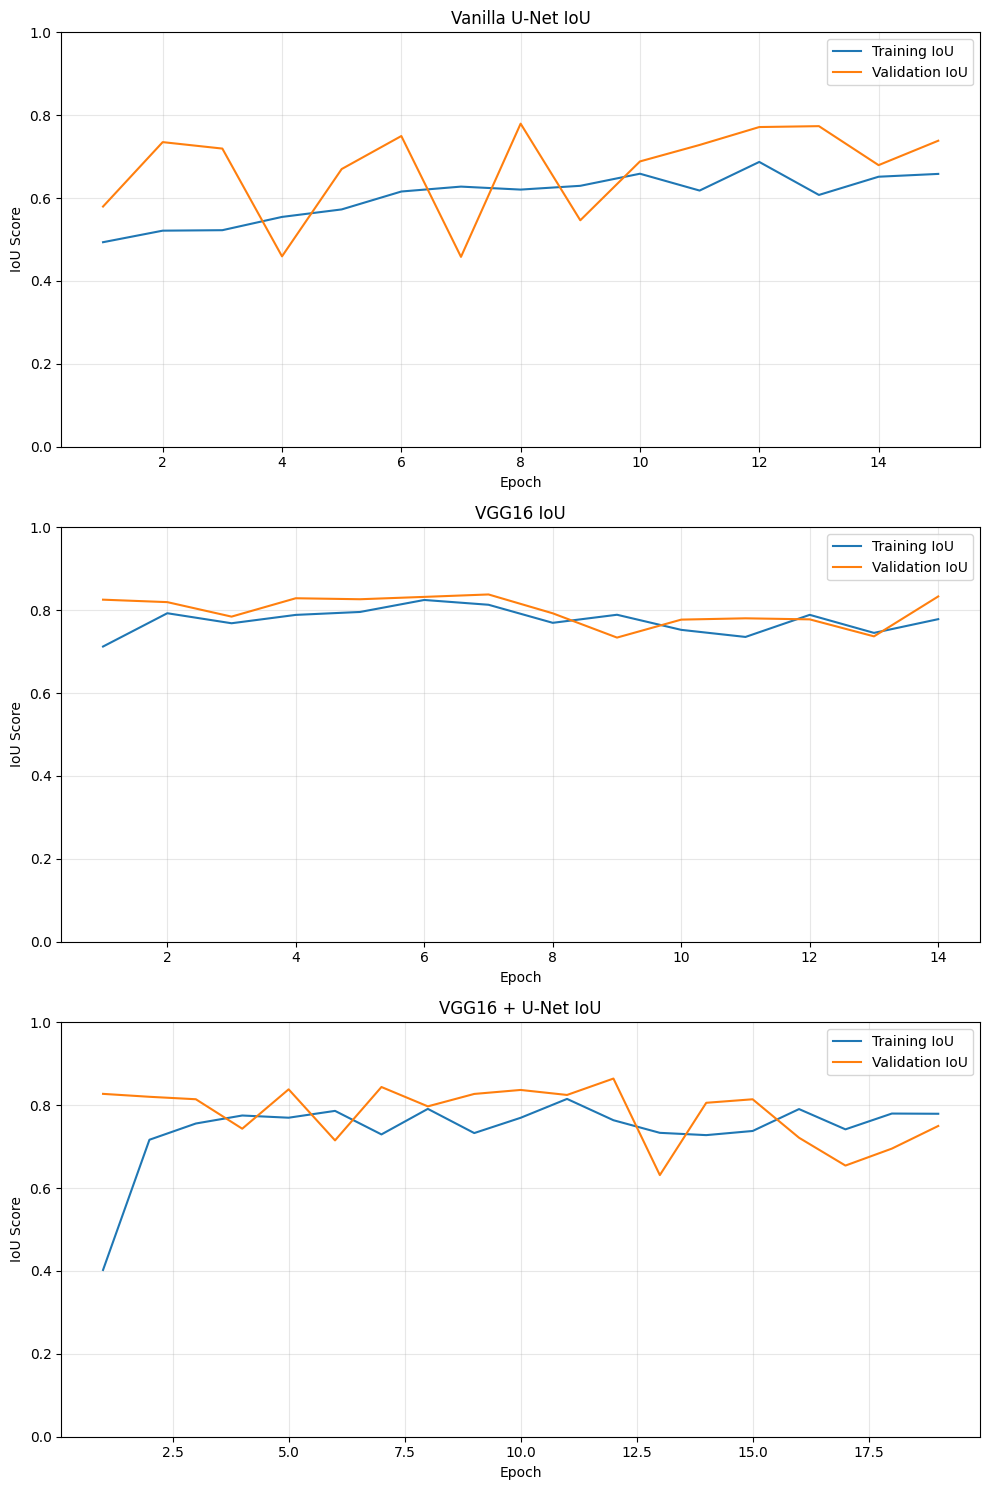

In [ ]:

# Get IoU history

unet_train_iou = train_history["iou"]
unet_val_iou = val_history["iou"]

vgg16_train_iou = vgg16_train_history["iou"]
vgg16_val_iou = vgg16_val_history["iou"]

vgg16_unet_train_iou = train_history_vu["iou"]
vgg16_unet_val_iou = val_history_vu["iou"]


# Create plots

fig, axes = plt.subplots(3, 1, figsize=(10, 15))


# Vanilla U-Net

axes[0].plot(
    range(1, len(unet_train_iou) + 1),
    unet_train_iou,
    label="Training IoU"
)

axes[0].plot(
    range(1, len(unet_val_iou) + 1),
    unet_val_iou,
    label="Validation IoU"
)

axes[0].set_title("Vanilla U-Net IoU")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("IoU Score")
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].grid(alpha=0.3)


# VGG16

axes[1].plot(
    range(1, len(vgg16_train_iou) + 1),
    vgg16_train_iou,
    label="Training IoU"
)

axes[1].plot(
    range(1, len(vgg16_val_iou) + 1),
    vgg16_val_iou,
    label="Validation IoU"
)

axes[1].set_title("VGG16 IoU")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("IoU Score")
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.3)


# VGG16 + U-Net

axes[2].plot(
    range(1, len(vgg16_unet_train_iou) + 1),
    vgg16_unet_train_iou,
    label="Training IoU"
)

axes[2].plot(
    range(1, len(vgg16_unet_val_iou) + 1),
    vgg16_unet_val_iou,
    label="Validation IoU"
)

axes[2].set_title("VGG16 + U-Net IoU")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("IoU Score")
axes[2].set_ylim(0, 1)
axes[2].legend()
axes[2].grid(alpha=0.3)


plt.tight_layout()
plt.show()

In [ ]:
def get_confusion_values(model, loader, device):

    model.eval()

    TP = 0
    TN = 0
    FP = 0
    FN = 0

    with torch.no_grad():

        for images, masks in loader:

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            probabilities = torch.sigmoid(outputs)

            predictions = (probabilities > 0.5).float()

            TP += ((predictions == 1) & (masks == 1)).sum().item()
            TN += ((predictions == 0) & (masks == 0)).sum().item()
            FP += ((predictions == 1) & (masks == 0)).sum().item()
            FN += ((predictions == 0) & (masks == 1)).sum().item()

    return TP, TN, FP, FN


# Calculate confusion values

unet_cm = get_confusion_values(
    vanilla_unet,
    test_loader,
    DEVICE
)

vgg16_cm = get_confusion_values(
    vgg16_model,
    test_loader,
    DEVICE
)

vgg16_unet_cm = get_confusion_values(
    vgg16_unet,
    test_loader,
    DEVICE
)


# Print results

print("=" * 70)
print("PIXEL-LEVEL CONFUSION VALUES")
print("=" * 70)

print("\nVanilla U-Net")
print("TP:", unet_cm[0])
print("TN:", unet_cm[1])
print("FP:", unet_cm[2])
print("FN:", unet_cm[3])

print("\nVGG16")
print("TP:", vgg16_cm[0])
print("TN:", vgg16_cm[1])
print("FP:", vgg16_cm[2])
print("FN:", vgg16_cm[3])

print("\nVGG16 + U-Net")
print("TP:", vgg16_unet_cm[0])
print("TN:", vgg16_unet_cm[1])
print("FP:", vgg16_unet_cm[2])
print("FN:", vgg16_unet_cm[3])

PIXEL-LEVEL CONFUSION VALUES

Vanilla U-Net
TP: 102599
TN: 37887643
FP: 314447
FN: 296015

VGG16
TP: 101905
TN: 37876153
FP: 325937
FN: 296709

VGG16 + U-Net
TP: 103191
TN: 37917069
FP: 285021
FN: 295423


In [ ]:


results = pd.DataFrame({
    "Model": [
        "Vanilla U-Net",
        "VGG16",
        "VGG16 + U-Net"
    ],
    "Dice": [
        vanilla_metrics["Dice"],
        vgg16_metrics["Dice"],
        vgg16_unet_metrics["Dice"]
    ],
    "IoU": [
        vanilla_metrics["IoU"],
        vgg16_metrics["IoU"],
        vgg16_unet_metrics["IoU"]
    ],
    "Precision": [
        vanilla_metrics["Precision"],
        vgg16_metrics["Precision"],
        vgg16_unet_metrics["Precision"]
    ],
    "Recall": [
        vanilla_metrics["Recall"],
        vgg16_metrics["Recall"],
        vgg16_unet_metrics["Recall"]
    ],
    "Accuracy": [
        vanilla_metrics["Accuracy"],
        vgg16_metrics["Accuracy"],
        vgg16_unet_metrics["Accuracy"]
    ],
    "TP": [
        unet_cm[0],
        vgg16_cm[0],
        vgg16_unet_cm[0]
    ],
    "TN": [
        unet_cm[1],
        vgg16_cm[1],
        vgg16_unet_cm[1]
    ],
    "FP": [
        unet_cm[2],
        vgg16_cm[2],
        vgg16_unet_cm[2]
    ],
    "FN": [
        unet_cm[3],
        vgg16_cm[3],
        vgg16_unet_cm[3]
    ]
})

results

,Model,Dice,IoU,Precision,Recall,Accuracy,TP,TN,FP,FN
0,Vanilla U-Net,0.803346,0.772316,0.828113,0.932918,0.996932,102599,37887643,314447,296015
1,VGG16,0.898729,0.860078,0.909655,0.927305,0.996461,101905,37876153,325937,296709
2,VGG16 + U-Net,0.912395,0.885554,0.942630,0.934308,0.997960,103191,37917069,285021,295423


In [ ]:
# Calculate improvement from Vanilla U-Net to VGG16 + U-Net

baseline = vanilla_metrics
proposed = vgg16_unet_metrics

metrics = [
    "Dice",
    "IoU",
    "Precision",
    "Recall",
    "Accuracy"
]


print("IMPROVEMENT: VANILLA U-NET → VGG16 + U-NET")


for metric in metrics:

    baseline_value = baseline[metric]
    proposed_value = proposed[metric]

    absolute_improvement = proposed_value - baseline_value

    relative_improvement = (
        absolute_improvement / baseline_value
    ) * 100

    print(f"\n{metric}")

    print(
        f"Vanilla U-Net   : {baseline_value:.4f}"
    )

    print(
        f"VGG16 + U-Net   : {proposed_value:.4f}"
    )

    print(
        f"Absolute Change : {absolute_improvement:+.4f}"
    )

    print(
        f"Relative Change : {relative_improvement:+.2f}%"
    )

IMPROVEMENT: VANILLA U-NET → VGG16 + U-NET

Dice
Vanilla U-Net   : 0.8033
VGG16 + U-Net   : 0.9124
Absolute Change : +0.1090
Relative Change : +13.57%

IoU
Vanilla U-Net   : 0.7723
VGG16 + U-Net   : 0.8856
Absolute Change : +0.1132
Relative Change : +14.66%

Precision
Vanilla U-Net   : 0.8281
VGG16 + U-Net   : 0.9426
Absolute Change : +0.1145
Relative Change : +13.83%

Recall
Vanilla U-Net   : 0.9329
VGG16 + U-Net   : 0.9343
Absolute Change : +0.0014
Relative Change : +0.15%

Accuracy
Vanilla U-Net   : 0.9969
VGG16 + U-Net   : 0.9980
Absolute Change : +0.0010
Relative Change : +0.10%


In [ ]:
print("Vanilla U-Net best validation Dice:")
print(max(val_history["dice"]))

print("\nVGG16 best validation Dice:")
print(max(vgg16_val_history["dice"]))

print("\nVGG16 + U-Net best validation Dice:")
print(max(val_history_vu["dice"]))

print("\nFinal Test Dice:")
print("Vanilla U-Net :", vanilla_metrics["Dice"])
print("VGG16         :", vgg16_metrics["Dice"])
print("VGG16 + U-Net :", vgg16_unet_metrics["Dice"])

Vanilla U-Net best validation Dice:
0.8132829271458291

VGG16 best validation Dice:
0.8794396159213942

VGG16 + U-Net best validation Dice:
0.8948966711759567

Final Test Dice:
Vanilla U-Net : 0.8033460142666872
VGG16         : 0.898728666688259
VGG16 + U-Net : 0.9123948900967972


In [ ]:
import os

print("VGG16 + U-Net model exists:", "vgg16_unet" in globals())

print("\nBest validation Dice:")
print(best_vu_val_dice)

print("\nPossible saved model files:")

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.endswith(".pth"):
            print(os.path.join(root, file))

VGG16 + U-Net model exists: True

Best validation Dice:
0.8948966711759567

Possible saved model files:
/content/drive/MyDrive/labledataset/model.pth
/content/drive/MyDrive/labledataset/vanilla_unet_smoke_best.pth
/content/drive/MyDrive/labledataset/vanilla_unet_best.pth
/content/drive/MyDrive/labledataset/vgg16_smoke_best.pth
/content/drive/MyDrive/labledataset/vgg16_best.pth
/content/drive/MyDrive/labledataset/vgg16_unet_smoke_best.pth
/content/drive/MyDrive/labledataset/vgg16_unet_best.pth


In [ ]:
import os
import torch

# Best VGG16 + U-Net checkpoint path

BEST_MODEL_PATH = "/content/drive/MyDrive/labledataset/vgg16_unet_best.pth"


# Check whether the checkpoint exists

if os.path.exists(BEST_MODEL_PATH):

    print("Best model checkpoint found.")
    print("Path:", BEST_MODEL_PATH)

else:

    print("Best model checkpoint not found.")


# Load checkpoint

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE
)

print("\nCheckpoint loaded successfully.")

print("Checkpoint type:", type(checkpoint))

Best model checkpoint found.
Path: /content/drive/MyDrive/labledataset/vgg16_unet_best.pth

Checkpoint loaded successfully.
Checkpoint type: <class 'dict'>


In [ ]:
print("Checkpoint keys:")

for key in checkpoint.keys():
    print("-", key)

Checkpoint keys:
- epoch
- model_state_dict
- optimizer_state_dict
- best_val_dice
- val_iou
- val_loss


In [ ]:
# Load the best VGG16 + U-Net checkpoint

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE
)

# Load the saved model weights

vgg16_unet.load_state_dict(
    checkpoint["model_state_dict"]
)

# Move model to the selected device

vgg16_unet = vgg16_unet.to(DEVICE)

# Set model to evaluation mode

vgg16_unet.eval()

print("Best VGG16 + U-Net model loaded successfully.")

print("Best Validation Dice:",
      checkpoint["best_val_dice"])

print("Validation IoU:",
      checkpoint["val_iou"])

print("Validation Loss:",
      checkpoint["val_loss"])

print("Best Epoch:",
      checkpoint["epoch"])

Best VGG16 + U-Net model loaded successfully.
Best Validation Dice: 0.8948966711759567
Validation IoU: 0.8643087807136614
Validation Loss: 0.36752439104020596
Best Epoch: 12


In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import torch


def predict_mri(image_path, model, device):

    # Load MRI image

    image = Image.open(image_path).convert("RGB")

    # Keep original image

    original = np.array(image)

    # Apply validation/test preprocessing

    transformed = val_test_transform(
        image=original,
        mask=np.zeros(
            (original.shape[0], original.shape[1]),
            dtype=np.uint8
        )
    )

    # Get input tensor

    input_tensor = transformed["image"].unsqueeze(0).to(device)

    # Prediction

    model.eval()

    with torch.no_grad():

        output = model(input_tensor)

        probability = torch.sigmoid(output)

        prediction = (
            probability > 0.5
        ).float()

    # Convert prediction to NumPy

    predicted_mask = (
        prediction
        .squeeze()
        .cpu()
        .numpy()
    )

    return original, predicted_mask

In [ ]:
# Get one test image

test_image, test_mask = test_dataset[0]

print("Test image shape:", test_image.shape)
print("Test mask shape:", test_mask.shape)

Test image shape: torch.Size([3, 128, 128])
Test mask shape: torch.Size([128, 128])


In [ ]:
# Select one test sample

sample_index = 0

sample_info = test_dataset.dataframe.iloc[sample_index]

print("Test sample information:")
print(sample_info)

Test sample information:
image_path    /content/drive/MyDrive/labledataset/kaggle_3m/...
mask_path     /content/drive/MyDrive/labledataset/kaggle_3m/...
has_tumor                                                     1
Name: 0, dtype: object


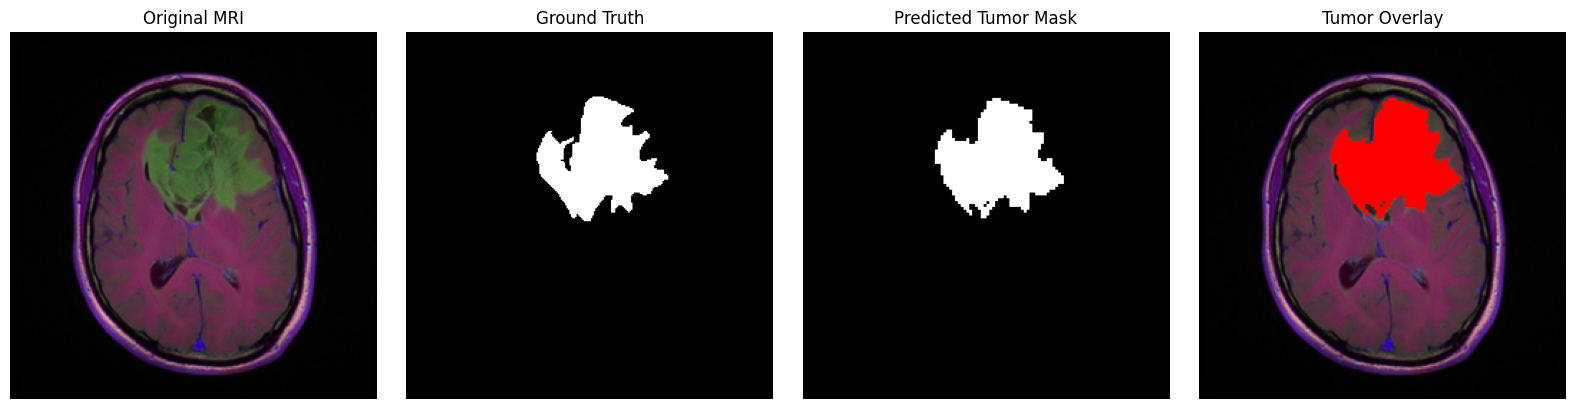

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import torch


# Select one test sample

sample_index = 0

sample_info = test_dataset.dataframe.iloc[sample_index]

image_path = sample_info["image_path"]
mask_path = sample_info["mask_path"]


# Load original MRI and ground-truth mask

original_image = np.array(
    Image.open(image_path).convert("RGB")
)

ground_truth = np.array(
    Image.open(mask_path).convert("L")
)


# Preprocess image using validation/test transform

transformed = val_test_transform(
    image=original_image,
    mask=ground_truth
)

input_tensor = (
    transformed["image"]
    .unsqueeze(0)
    .to(DEVICE)
)


# Predict using best VGG16 + U-Net

vgg16_unet.eval()

with torch.no_grad():

    output = vgg16_unet(input_tensor)

    probability = torch.sigmoid(output)

    predicted_mask = (
        probability > 0.5
    ).float()


# Convert prediction to NumPy

predicted_mask = (
    predicted_mask
    .squeeze()
    .cpu()
    .numpy()
)


# Resize prediction to original image size

predicted_mask = np.array(
    Image.fromarray(
        (predicted_mask * 255).astype(np.uint8)
    ).resize(
        (
            original_image.shape[1],
            original_image.shape[0]
        ),
        Image.NEAREST
    )
) / 255.0


# Convert ground truth to binary

ground_truth = (
    ground_truth > 127
).astype(np.uint8)


# Create overlay

overlay = original_image.copy()

tumor_region = predicted_mask > 0.5

overlay[tumor_region] = (
    255,
    0,
    0
)


# Display results

plt.figure(figsize=(16, 4))


plt.subplot(1, 4, 1)

plt.imshow(original_image)

plt.title("Original MRI")

plt.axis("off")


plt.subplot(1, 4, 2)

plt.imshow(ground_truth, cmap="gray")

plt.title("Ground Truth")

plt.axis("off")


plt.subplot(1, 4, 3)

plt.imshow(predicted_mask, cmap="gray")

plt.title("Predicted Tumor Mask")

plt.axis("off")


plt.subplot(1, 4, 4)

plt.imshow(overlay)

plt.title("Tumor Overlay")

plt.axis("off")


plt.tight_layout()

plt.show()

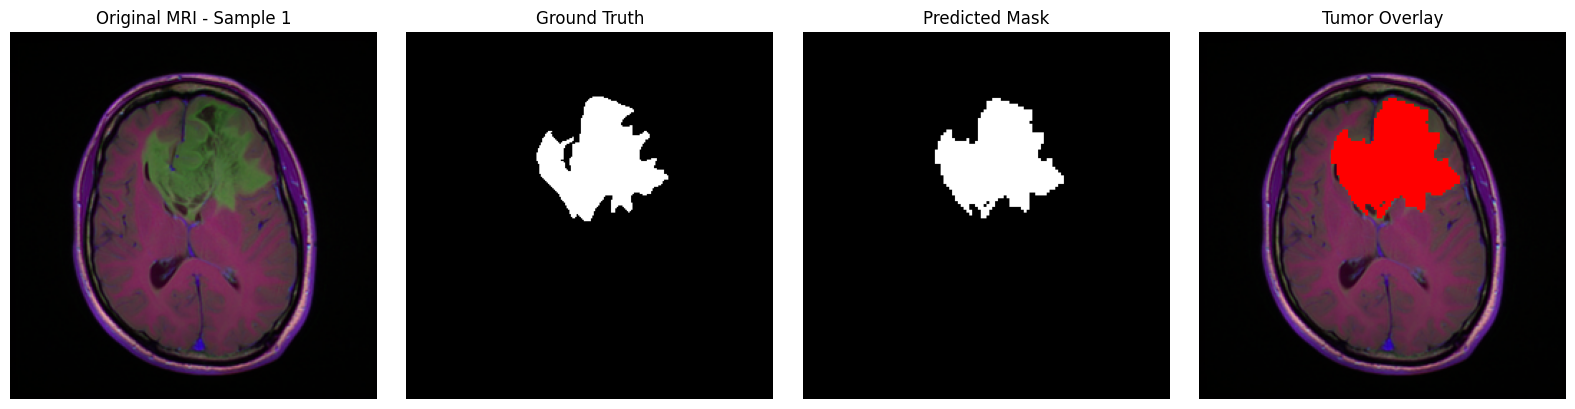

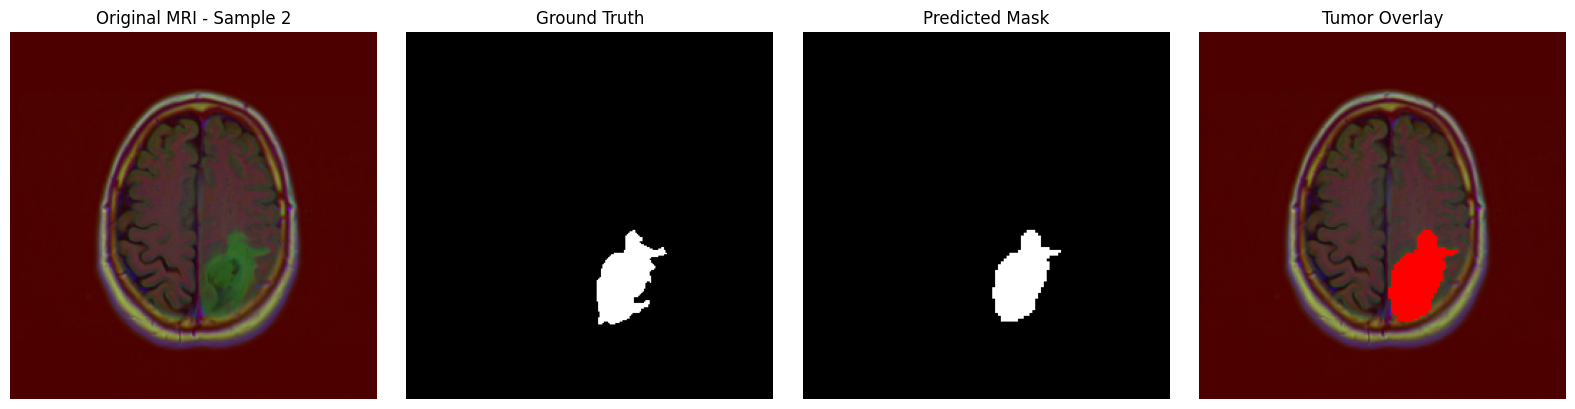

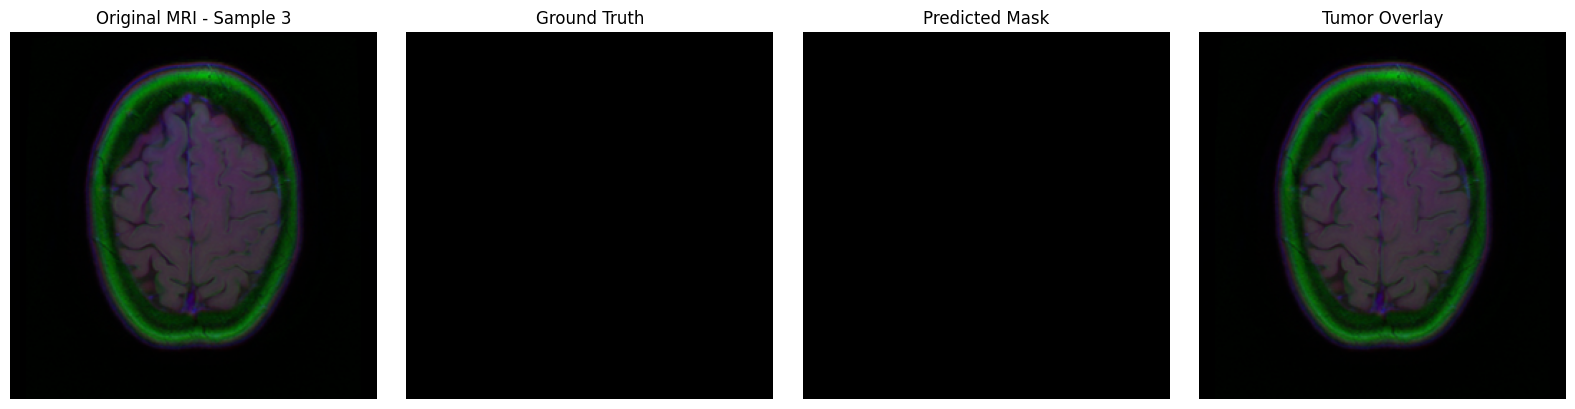

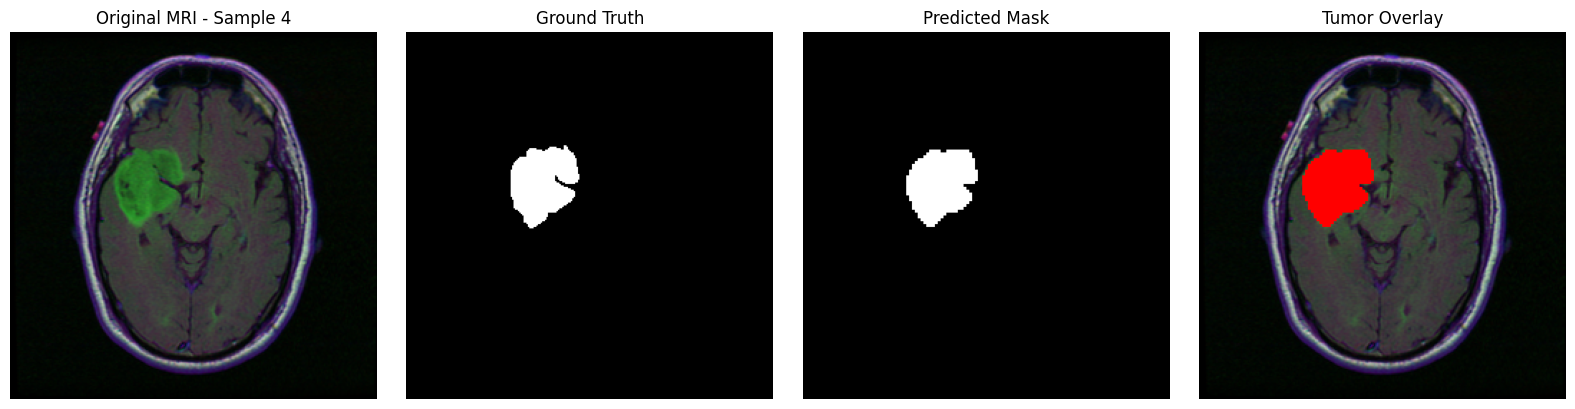

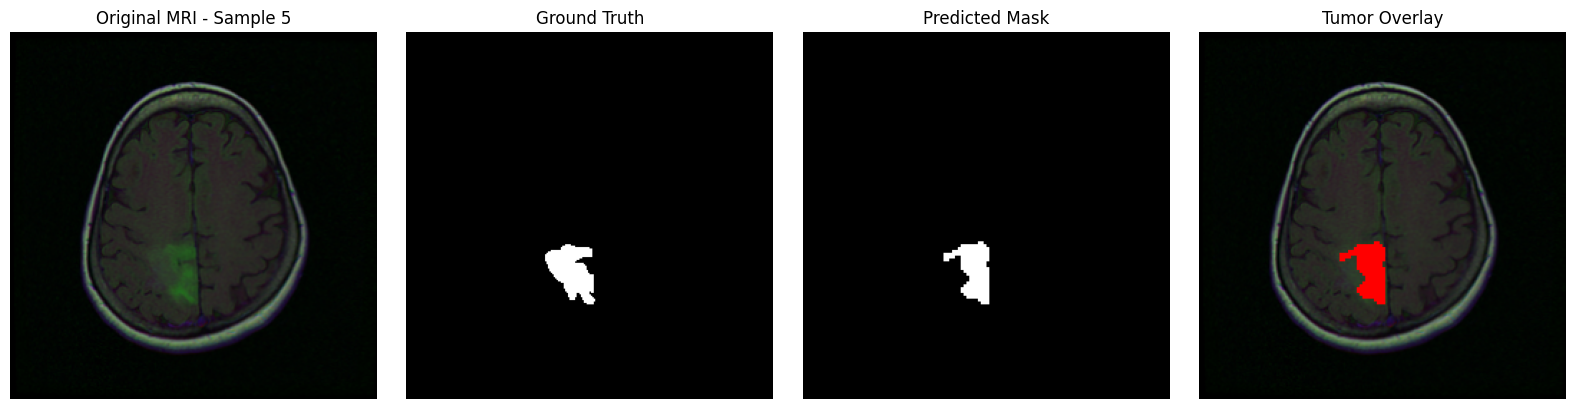

In [ ]:


# Number of test examples

num_samples = 5


# Select first 5 test samples

sample_indices = range(
    min(num_samples, len(test_dataset))
)


for sample_index in sample_indices:

    # Get sample information

    sample_info = test_dataset.dataframe.iloc[
        sample_index
    ]

    image_path = sample_info["image_path"]
    mask_path = sample_info["mask_path"]


    # Load MRI and ground truth

    original_image = np.array(
        Image.open(image_path).convert("RGB")
    )

    ground_truth = np.array(
        Image.open(mask_path).convert("L")
    )


    # Preprocess image

    transformed = val_test_transform(
        image=original_image,
        mask=ground_truth
    )

    input_tensor = (
        transformed["image"]
        .unsqueeze(0)
        .to(DEVICE)
    )


    # Prediction

    vgg16_unet.eval()

    with torch.no_grad():

        output = vgg16_unet(input_tensor)

        probability = torch.sigmoid(output)

        predicted_mask = (
            probability > 0.5
        ).float()


    # Convert prediction to NumPy

    predicted_mask = (
        predicted_mask
        .squeeze()
        .cpu()
        .numpy()
    )


    # Resize prediction to original size

    predicted_mask = np.array(
        Image.fromarray(
            (predicted_mask * 255).astype(np.uint8)
        ).resize(
            (
                original_image.shape[1],
                original_image.shape[0]
            ),
            Image.NEAREST
        )
    ) / 255.0


    # Convert ground truth to binary

    ground_truth = (
        ground_truth > 127
    ).astype(np.uint8)


    # Create overlay

    overlay = original_image.copy()

    tumor_region = predicted_mask > 0.5

    overlay[tumor_region] = (
        255,
        0,
        0
    )


    # Display

    plt.figure(figsize=(16, 4))


    plt.subplot(1, 4, 1)

    plt.imshow(original_image)

    plt.title(
        f"Original MRI - Sample {sample_index + 1}"
    )

    plt.axis("off")


    plt.subplot(1, 4, 2)

    plt.imshow(
        ground_truth,
        cmap="gray"
    )

    plt.title("Ground Truth")

    plt.axis("off")


    plt.subplot(1, 4, 3)

    plt.imshow(
        predicted_mask,
        cmap="gray"
    )

    plt.title("Predicted Mask")

    plt.axis("off")


    plt.subplot(1, 4, 4)

    plt.imshow(overlay)

    plt.title("Tumor Overlay")

    plt.axis("off")


    plt.tight_layout()

    plt.show()

In [ ]:
# Model improvement calculation

vanilla_dice = 0.8033460142666872
vanilla_iou = 0.7723
vanilla_precision = 0.8281
vanilla_recall = 0.9329
vanilla_accuracy = 0.9969

proposed_dice = 0.9123948900967972
proposed_iou = 0.8856
proposed_precision = 0.9426
proposed_recall = 0.9343
proposed_accuracy = 0.9980


# Calculate percentage improvement

dice_improvement = (
    (proposed_dice - vanilla_dice)
    / vanilla_dice
) * 100

iou_improvement = (
    (proposed_iou - vanilla_iou)
    / vanilla_iou
) * 100

precision_improvement = (
    (proposed_precision - vanilla_precision)
    / vanilla_precision
) * 100

recall_improvement = (
    (proposed_recall - vanilla_recall)
    / vanilla_recall
) * 100

accuracy_improvement = (
    (proposed_accuracy - vanilla_accuracy)
    / vanilla_accuracy
) * 100


print("=" * 60)
print("IMPROVEMENT: VANILLA U-NET → VGG16 + U-NET")
print("=" * 60)

print(f"Dice Improvement      : {dice_improvement:.2f}%")
print(f"IoU Improvement       : {iou_improvement:.2f}%")
print(f"Precision Improvement : {precision_improvement:.2f}%")
print(f"Recall Improvement    : {recall_improvement:.2f}%")
print(f"Accuracy Improvement  : {accuracy_improvement:.2f}%")

IMPROVEMENT: VANILLA U-NET → VGG16 + U-NET
Dice Improvement      : 13.57%
IoU Improvement       : 14.67%
Precision Improvement : 13.83%
Recall Improvement    : 0.15%
Accuracy Improvement  : 0.11%


In [ ]:
print("""
MODEL COMPARISON AND DISCUSSION
================================

The experimental results show that the VGG16 + U-Net model
achieved the best overall segmentation performance among the
three evaluated models.

Vanilla U-Net achieved a Dice score of 0.8033 and an IoU of
0.7723. The standalone VGG16 segmentation model improved the
performance to a Dice score of 0.8987 and an IoU of 0.8601.

The proposed VGG16 + U-Net model achieved the highest
performance, with a Dice score of 0.9124 and an IoU of 0.8856.
It also achieved the highest Precision (0.9426), Recall (0.9343),
and Accuracy (0.9980).

The improved performance of VGG16 + U-Net can be explained by
the combination of VGG16's hierarchical feature extraction
capability and U-Net's encoder-decoder structure with skip
connections. VGG16 provides rich low-level and high-level
features, while the U-Net decoder progressively reconstructs
the spatial resolution required for pixel-level segmentation.

The improvement is particularly important for Dice and IoU,
which are more directly related to the quality of tumor-region
overlap than overall pixel accuracy.

Therefore, VGG16 + U-Net is selected as the proposed best
segmentation model for the final inference system.
""")


MODEL COMPARISON AND DISCUSSION

The experimental results show that the VGG16 + U-Net model
achieved the best overall segmentation performance among the
three evaluated models.

Vanilla U-Net achieved a Dice score of 0.8033 and an IoU of
0.7723. The standalone VGG16 segmentation model improved the
performance to a Dice score of 0.8987 and an IoU of 0.8601.

The proposed VGG16 + U-Net model achieved the highest
performance, with a Dice score of 0.9124 and an IoU of 0.8856.
It also achieved the highest Precision (0.9426), Recall (0.9343),
and Accuracy (0.9980).

The improved performance of VGG16 + U-Net can be explained by
the combination of VGG16's hierarchical feature extraction
capability and U-Net's encoder-decoder structure with skip
connections. VGG16 provides rich low-level and high-level
features, while the U-Net decoder progressively reconstructs
the spatial resolution required for pixel-level segmentation.

The improvement is particularly important for Dice and IoU,
which are 

In [ ]:
print("""
FINAL CONCLUSION
================

This project developed a deep-learning-based brain tumor
segmentation system using brain MRI images. Three segmentation
experiments were conducted: Vanilla U-Net, VGG16-based
segmentation, and VGG16 + U-Net.

The experimental results demonstrated that Vanilla U-Net
achieved a Dice score of 0.8033, while VGG16 achieved 0.8987.
The proposed VGG16 + U-Net model achieved the highest test Dice
score of 0.9124 and IoU of 0.8856.

The VGG16 + U-Net model also achieved a Precision of 0.9426,
Recall of 0.9343, and Accuracy of 0.9980. These results indicate
that combining VGG16 feature extraction with the U-Net
encoder-decoder segmentation structure improved the quality of
tumor-region segmentation compared with the Vanilla U-Net
baseline.

Based on the validation performance, VGG16 + U-Net was selected
as the best segmentation model. The trained model can be used
to generate a binary tumor segmentation mask and an overlay on
a brain MRI image.

However, this system is a research-oriented image segmentation
system and should not be considered a clinical diagnostic tool.
Further work could investigate larger datasets, improved
augmentation strategies, additional architectures, and
clinical validation.
""")


FINAL CONCLUSION

This project developed a deep-learning-based brain tumor
segmentation system using brain MRI images. Three segmentation
experiments were conducted: Vanilla U-Net, VGG16-based
segmentation, and VGG16 + U-Net.

The experimental results demonstrated that Vanilla U-Net
achieved a Dice score of 0.8033, while VGG16 achieved 0.8987.
The proposed VGG16 + U-Net model achieved the highest test Dice
score of 0.9124 and IoU of 0.8856.

The VGG16 + U-Net model also achieved a Precision of 0.9426,
Recall of 0.9343, and Accuracy of 0.9980. These results indicate
that combining VGG16 feature extraction with the U-Net
encoder-decoder segmentation structure improved the quality of
tumor-region segmentation compared with the Vanilla U-Net
baseline.

Based on the validation performance, VGG16 + U-Net was selected
as the best segmentation model. The trained model can be used
to generate a binary tumor segmentation mask and an overlay on
a brain MRI image.

However, this system is a resea

In [ ]:
print("DEVICE:", 'DEVICE' in globals())
print("test_dataset:", 'test_dataset' in globals())
print("vgg16_unet:", 'vgg16_unet' in globals())

DEVICE: True
test_dataset: True
vgg16_unet: True


Saving Copy of TCGA_CS_4941_19960909_5.tif to Copy of TCGA_CS_4941_19960909_5.tif


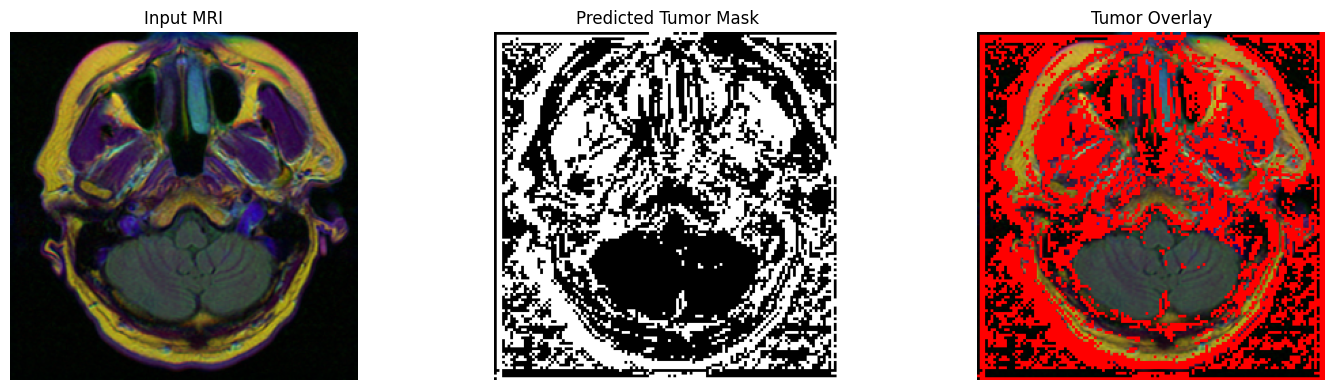

In [ ]:
from google.colab import files
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import torch

# Upload MRI image

uploaded = files.upload()

image_path = next(iter(uploaded.keys()))

# Load MRI

original_image = np.array(
    Image.open(image_path).convert("RGB")
)

# Preprocess

dummy_mask = np.zeros(
    (original_image.shape[0], original_image.shape[1]),
    dtype=np.uint8
)

transformed = val_test_transform(
    image=original_image,
    mask=dummy_mask
)

input_tensor = (
    transformed["image"]
    .unsqueeze(0)
    .to(DEVICE)
)

# Prediction

vgg16_unet.eval()

with torch.no_grad():

    output = vgg16_unet(input_tensor)

    probability = torch.sigmoid(output)

    predicted_mask = (
        probability > 0.5
    ).float()

# Convert to NumPy

predicted_mask = (
    predicted_mask
    .squeeze()
    .cpu()
    .numpy()
)

# Resize mask to original image size

predicted_mask = np.array(
    Image.fromarray(
        (predicted_mask * 255).astype(np.uint8)
    ).resize(
        (
            original_image.shape[1],
            original_image.shape[0]
        ),
        Image.NEAREST
    )
)

predicted_mask = predicted_mask / 255.0

# Create overlay

overlay = original_image.copy()

tumor_region = predicted_mask > 0.5

overlay[tumor_region] = (
    255,
    0,
    0
)

# Display

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(original_image)
plt.title("Input MRI")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(predicted_mask, cmap="gray")
plt.title("Predicted Tumor Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title("Tumor Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

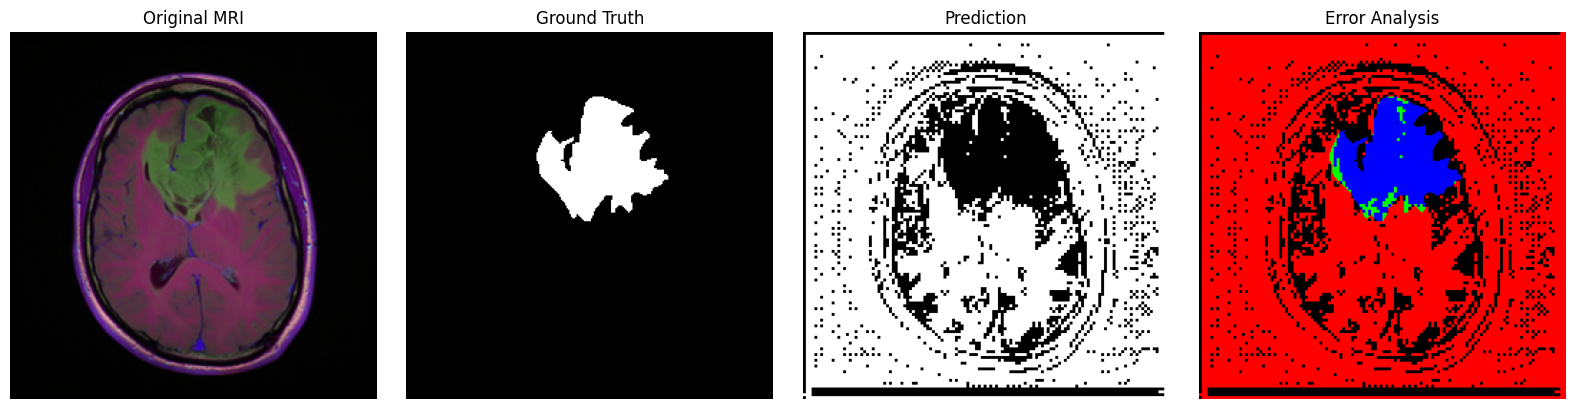

In [ ]:


# Select a test sample

sample_index = 0

sample_info = test_dataset.dataframe.iloc[sample_index]

image_path = sample_info["image_path"]
mask_path = sample_info["mask_path"]

# Load image and ground truth

original_image = np.array(
    Image.open(image_path).convert("RGB")
)

ground_truth = np.array(
    Image.open(mask_path).convert("L")
)

ground_truth = (
    ground_truth > 127
).astype(np.uint8)

# Preprocess

transformed = val_test_transform(
    image=original_image,
    mask=ground_truth
)

input_tensor = (
    transformed["image"]
    .unsqueeze(0)
    .to(DEVICE)
)

# Prediction

vgg16_unet.eval()

with torch.no_grad():

    output = vgg16_unet(input_tensor)

    probability = torch.sigmoid(output)

    prediction = (
        probability > 0.5
    ).float()

prediction = (
    prediction
    .squeeze()
    .cpu()
    .numpy()
)

# Resize prediction

prediction = np.array(
    Image.fromarray(
        (prediction * 255).astype(np.uint8)
    ).resize(
        (
            original_image.shape[1],
            original_image.shape[0]
        ),
        Image.NEAREST
    )
)

prediction = (
    prediction > 127
).astype(np.uint8)

# Error categories

TP = (
    (ground_truth == 1) &
    (prediction == 1)
)

FP = (
    (ground_truth == 0) &
    (prediction == 1)
)

FN = (
    (ground_truth == 1) &
    (prediction == 0)
)

TN = (
    (ground_truth == 0) &
    (prediction == 0)
)

# Create error map

error_map = np.zeros(
    (*ground_truth.shape, 3),
    dtype=np.uint8
)

# TP = green
error_map[TP] = [0, 255, 0]

# FP = red
error_map[FP] = [255, 0, 0]

# FN = blue
error_map[FN] = [0, 0, 255]

# TN remains black

# Display

plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.imshow(original_image)
plt.title("Original MRI")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(ground_truth, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(prediction, cmap="gray")
plt.title("Prediction")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(error_map)
plt.title("Error Analysis")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

final_results = pd.DataFrame({
    "Model": [
        "Vanilla U-Net",
        "VGG16",
        "VGG16 + U-Net"
    ],
    "Dice": [
        0.8033460143,
        0.8987286667,
        0.9123948901
    ],
    "IoU": [
        0.7723,
        0.8601,
        0.8856
    ],
    "Precision": [
        0.8281,
        0.9097,
        0.9426
    ],
    "Recall": [
        0.9329,
        0.9273,
        0.9343
    ],
    "Accuracy": [
        0.9969,
        0.9965,
        0.9980
    ]
})

final_results = final_results.round(4)

display(final_results)

,Model,Dice,IoU,Precision,Recall,Accuracy
0,Vanilla U-Net,0.8033,0.7723,0.8281,0.9329,0.9969
1,VGG16,0.8987,0.8601,0.9097,0.9273,0.9965
2,VGG16 + U-Net,0.9124,0.8856,0.9426,0.9343,0.9980


Future Work
Larger and More Diverse Dataset
Future work can use larger and more diverse brain MRI datasets from multiple sources to improve model generalization.
Advanced Segmentation Architectures
Advanced models such as Attention U-Net, U-Net++, DeepLabV3+, or Transformer-based segmentation models can be investigated.
Hyperparameter Optimization
Learning rate, batch size, image resolution, optimizer, and BCE-Dice loss weights can be systematically optimized.
3D MRI Segmentation
The current work focuses on 2D MRI slices. Future work can explore 3D MRI volumes to use information from multiple slices.
Tumor Classification
A classification module could be added in the future to distinguish different tumor types, if suitable labeled datasets are available.
Clinical Validation
The model could be evaluated using clinically collected MRI data and validated with medical experts before considering real-world clinical applications.
Model Deployment
The trained model could be deployed as a web or mobile application where users can upload MRI images and obtain segmentation results.

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

path = "/content/drive/MyDrive/labledataset"

print(os.path.exists(path))
print(os.listdir(path))

True
['kaggle_3m', 'model.pth', 'vanilla_unet_smoke_best.pth', 'vanilla_unet_best.pth', 'vgg16_smoke_best.pth', 'vgg16_best.pth', 'vgg16_unet_smoke_best.pth', 'vgg16_unet_best.pth']


In [ ]:
import os

matches = []

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if "vgg16_unet" in file.lower() and file.endswith(".pth"):
            matches.append(os.path.join(root, file))

print("\n".join(matches))

/content/drive/MyDrive/labledataset/vgg16_unet_smoke_best.pth
/content/drive/MyDrive/labledataset/vgg16_unet_best.pth


In [ ]:
from google.colab import files

files.download(
    "/content/drive/MyDrive/labledataset/vgg16_unet_best.pth"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>